In [1]:
# =========================================================
# 0. Imports
# =========================================================
from __future__ import annotations

import os
import json
import copy
import pickle
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import xarray as xr
import random

PROJECT_ROOT = Path.cwd().resolve().parents[0]
sys.path.insert(0, str(PROJECT_ROOT))

import trace_st as tst


import matplotlib.gridspec as gridspec
from matplotlib.lines import Line2D
from matplotlib.patches import Rectangle
from matplotlib.collections import LineCollection

import matplotlib.font_manager as fm
# ------------------------------------------------------------
# Font setup (Helvetica Regular + Bold)
# ------------------------------------------------------------
font_dir = "/glade/u/home/jhayron/Causality_CaStLe/PaperCausalBTs/Helvetica"

regular_font = os.path.join(font_dir, "Helvetica.ttf")
bold_font = os.path.join(font_dir, "Helvetica-Bold.ttf")

if os.path.exists(regular_font):
    fm.fontManager.addfont(regular_font)

if os.path.exists(bold_font):
    fm.fontManager.addfont(bold_font)

mpl.rcParams["font.family"] = "Helvetica"
mpl.rcParams["font.weight"] = "regular"

mpl.rcParams.update({
    # --------------------------------------------------
    # FONT FAMILY
    # --------------------------------------------------
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica"],

    # --------------------------------------------------
    # WEIGHTS
    # --------------------------------------------------
    "font.weight": "regular",
    "axes.titleweight": "bold",
    "axes.labelweight": "regular",

    # --------------------------------------------------
    # FONT SIZES (optional but recommended)
    # --------------------------------------------------
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 9,

    # --------------------------------------------------
    # IMPORTANT: MATH TEXT → match Helvetica
    # --------------------------------------------------
    "mathtext.fontset": "custom",
    "mathtext.rm": "Helvetica",
    "mathtext.it": "Helvetica:italic",
    "mathtext.bf": "Helvetica:bold",
    "mathtext.cal": "Helvetica",   # ← THIS fixes the warning

    # --------------------------------------------------
    # PDF / VECTOR EXPORT (VERY IMPORTANT FOR PAPERS)
    # --------------------------------------------------
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

mpl.rcParams.update({

    # -------------------------
    # FONT FAMILY
    # -------------------------
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica"],

    # -------------------------
    # BASE SIZE (master control)
    # -------------------------
    "font.size": 11,

    # -------------------------
    # TITLES
    # -------------------------
    "axes.titlesize": 13,
    "axes.titleweight": "bold",

    # -------------------------
    # AXIS LABELS
    # -------------------------
    "axes.labelsize": 11,

    # -------------------------
    # TICKS
    # -------------------------
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,

    # -------------------------
    # LEGENDS
    # -------------------------
    "legend.fontsize": 9,

    # -------------------------
    # COLORBAR
    # -------------------------
    "axes.labelweight": "regular",

    # -------------------------
    # MATH TEXT (critical)
    # -------------------------
    "mathtext.fontset": "custom",
    "mathtext.rm": "Helvetica",
    "mathtext.it": "Helvetica:italic",
    "mathtext.bf": "Helvetica:bold",
    "mathtext.cal": "Helvetica",

    # -------------------------
    # VECTOR EXPORT
    # -------------------------
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})


In [2]:
# =========================================================
# 1. Paths and basic config
# =========================================================
OUT_ROOT = Path("/glade/derecho/scratch/jhayron/DataCaStLeBTs/Results_HW_PNW21_v3/")
SUMMARY_CSV = OUT_ROOT / "hyperparam_search_summary.csv"
SUMMARY_PKL = OUT_ROOT / "hyperparam_search_summary.pkl"

# optional: event info for plotting
event_lat = 52.5
event_lon = 240.0

# optional: set this if you want to reload the original data for plotting densities
PATH_FILES = "/glade/derecho/scratch/jhayron/DataCaStLeBTs/JointFiles/"
TIME_SLICE = ("2021-05-20", "2021-06-30")

VAR_NAME_MAP = {
    "z500": "Z500",
    "olr": "MTNLWRF",
    "skt": "SKT",
    "slhf": "MSLHF",
    "sshf": "MSSHF",
    "tclw": "TCLW",
    "tcwv": "TCWV",
    "vimd": "MVIMD",
    "w500": "W500",
    "z100": "Z100",
    "z10": "Z10",
}

VAR_COMBO = ["z500", "z10", "olr", "tcwv", "slhf", "sshf"]
date_end = "2021-06-30"

In [3]:
def load_full_data_for_vars(varstems: List[str]) -> xr.DataArray:
    list_names = [VAR_NAME_MAP[v] for v in varstems]
    full_data = tst.data_io.load_full_data(
        path_files=PATH_FILES,
        varstems=varstems,
        list_names_vars=list_names,
        time_slice=TIME_SLICE,
        join="inner",
    )
    return full_data

In [4]:
full_data_run = load_full_data_for_vars(VAR_COMBO)

In [5]:
# define target 2.5° grid
new_lats = np.arange(-30, 90.0 + 2.5, 2.5)
new_lons = np.arange(0, 360, 2.5)

full_data_run_2p5 = full_data_run.interp(
    lat=new_lats,
    lon=new_lons,
    method="linear"
)

print(full_data_run_2p5)

full_data_run = full_data_run_2p5

<xarray.DataArray 'z500' (var: 6, lat: 49, lon: 144, time: 42)> Size: 14MB
array([[[[-1.02841532, -0.00930475,  0.24308337, ..., -2.48365927,
          -1.63520002,  0.25249168],
         [-1.22718322, -0.18940932,  0.32770862, ..., -2.45128524,
          -1.93025327, -0.022622  ],
         [-1.39487946, -0.38274649,  0.35252264, ..., -2.30190587,
          -2.2007463 , -0.29980236],
         ...,
         [-0.35484366,  0.22470157, -0.36685538, ..., -1.66578263,
          -0.47627376,  0.92368698],
         [-0.58200592,  0.21778741, -0.12301873, ..., -2.10458732,
          -0.87967473,  0.75397456],
         [-0.80948234,  0.14760059,  0.0892944 , ..., -2.37346721,
          -1.28020626,  0.52777605]],

        [[-0.96217132, -0.14013359,  0.25782384, ..., -2.9848671 ,
          -1.65576196,  0.6082384 ],
         [-1.03806537, -0.28063367,  0.26809442, ..., -2.88445199,
          -2.11572498,  0.30429885],
         [-1.09197736, -0.41250648,  0.25116808, ..., -2.56116915,
          

In [6]:
# =========================================================
# 2. Load summary table
# =========================================================
if SUMMARY_PKL.exists():
    df = pd.read_pickle(SUMMARY_PKL)
else:
    df = pd.read_csv(SUMMARY_CSV)

print(df.shape)
display(df.head())

(300, 128)


,run_id,n_requested,n_success,n_failed,success_rate,mean_steps,median_steps,min_steps,max_steps,fraction_full_length,...,days_21_30_parent_freq_norm_MTNLWRF,days_21_30_parent_freq_norm_TCWV,days_21_30_parent_freq_norm_MSLHF,days_21_30_parent_freq_norm_MSSHF,days_21_30_top5frac_Z500,days_21_30_top5frac_Z10,days_21_30_top5frac_MTNLWRF,days_21_30_top5frac_TCWV,days_21_30_top5frac_MSLHF,days_21_30_top5frac_MSSHF
0,0,30,30,0,1.0,26.800000,31.0,13,31,0.000000,...,0.330275,0.160550,0.224771,0.229358,1.000000,NaN,0.485006,0.582349,0.700227,0.488444
1,1,30,30,0,1.0,26.266667,31.0,10,31,0.000000,...,0.236967,0.132701,0.265403,0.350711,1.000000,NaN,0.514667,0.605728,0.531983,0.444224
2,2,30,30,0,1.0,23.166667,30.5,3,31,0.033333,...,0.205556,0.133333,0.255556,0.344444,0.929449,1.0,0.491316,0.545735,0.477922,0.449662
3,3,30,30,0,1.0,17.133333,17.0,4,31,0.000000,...,0.252874,0.114943,0.344828,0.275862,NaN,1.0,0.569545,0.765075,0.483222,0.415762
4,4,30,30,0,1.0,20.300000,22.0,7,31,0.000000,...,0.160584,0.262774,0.233577,0.299270,1.000000,1.0,0.618096,0.459323,0.427694,0.584459


In [7]:
# =========================================================
# 3. Quick overview
# =========================================================
basic_cols = [
    "run_id",
    "n_requested",
    "n_success",
    "n_failed",
    "success_rate",
    "mean_steps",
    "fraction_full_length",
    "mean_displacement_km",
    "mean_path_length_km",
    "mean_unique_parents",
    "parent_entropy_all",
    "step_10_mean_radius_km",
    "step_20_mean_radius_km",
    "step_30_mean_radius_km",
]

display(df[basic_cols].describe().T)

,count,mean,std,min,25%,50%,75%,max
run_id,300.0,149.500000,86.746758,0.000000,74.750000,149.500000,224.250000,299.000000
n_requested,300.0,30.000000,0.000000,30.000000,30.000000,30.000000,30.000000,30.000000
n_success,300.0,30.000000,0.000000,30.000000,30.000000,30.000000,30.000000,30.000000
n_failed,300.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
success_rate,300.0,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000
mean_steps,300.0,24.111778,3.237739,14.500000,22.291667,24.316667,26.266667,31.000000
fraction_full_length,300.0,0.007667,0.015557,0.000000,0.000000,0.000000,0.000000,0.066667
mean_displacement_km,300.0,3636.897470,680.802489,2325.057698,3147.098242,3545.959266,4064.615270,5974.643957
mean_path_length_km,300.0,17777.686387,2961.592828,10213.442541,15590.440155,17250.368693,20023.162916,25917.791860
mean_unique_parents,300.0,5.029000,0.293025,4.066667,4.833333,5.000000,5.233333,5.733333


In [8]:
# =========================================================
# 4. Filter unusable runs
# =========================================================
df_filt = df.copy()

# Convert key columns safely
for col in [
    "success_rate",
    "mean_steps",
    "median_steps",
    "fraction_full_length",
    "mean_displacement_km",
    "mean_path_length_km",
    "step_10_mean_radius_km",
    "step_20_mean_radius_km",
    "step_30_mean_radius_km",
    "mean_unique_parents",
    "parent_entropy_all",
]:
    if col in df_filt.columns:
        df_filt[col] = pd.to_numeric(df_filt[col], errors="coerce")

print("Total runs:", len(df_filt))

# Set your initial filters here
MIN_SUCCESS_RATE = 0.66
MIN_MEAN_STEPS = 25
MIN_MEAN_PATH_LENGTH = 0

mask_keep = (
    (df_filt["success_rate"] >= MIN_SUCCESS_RATE) &
    (df_filt["median_steps"] >= MIN_MEAN_STEPS) &
    (df_filt["mean_path_length_km"] >= MIN_MEAN_PATH_LENGTH)
)

df_keep = df_filt.loc[mask_keep].copy()

print("Kept runs:", len(df_keep))
print("Dropped runs:", len(df_filt) - len(df_keep))
display(
    df_keep[
        [
            "run_id",
            "success_rate",
            "mean_steps",
            "mean_displacement_km",
            "mean_path_length_km",
        ]
    ].sort_values(["success_rate", "mean_steps"], ascending=False).head(20)
)

# Optional: inspect what got filtered out
df_drop = df_filt.loc[~mask_keep].copy()

display(
    df_drop[
        [
            "run_id",
            "success_rate",
            "mean_steps",
            "mean_displacement_km",
            "mean_path_length_km",
        ]
    ].sort_values(["mean_steps"], ascending=True).head(20)
)

Total runs: 300
Kept runs: 242
Dropped runs: 58


,run_id,success_rate,mean_steps,mean_displacement_km,mean_path_length_km
229,229,1.0,31.000000,5015.884151,19952.508206
259,259,1.0,30.833333,4190.100493,19101.351434
48,48,1.0,30.466667,4486.832247,19282.969543
21,21,1.0,30.333333,3134.810521,17554.661936
13,13,1.0,30.300000,4216.739825,16863.074616
237,237,1.0,30.166667,4266.733845,20224.491158
30,30,1.0,30.100000,3914.227217,15868.625957
173,173,1.0,30.033333,5432.859809,22806.050512
205,205,1.0,30.000000,5396.076034,21164.755976
227,227,1.0,29.900000,3539.156423,14068.600496


,run_id,success_rate,mean_steps,mean_displacement_km,mean_path_length_km
100,100,1.0,14.500000,3631.041460,15102.337397
190,190,1.0,14.700000,3030.435811,13629.859977
166,166,1.0,15.133333,2516.335482,10213.442541
201,201,1.0,15.733333,3346.166167,15197.615176
255,255,1.0,15.833333,3329.999616,13358.350706
39,39,1.0,16.300000,3652.414844,16081.241517
180,180,1.0,16.400000,3567.441243,15516.827451
290,290,1.0,16.800000,3557.074162,15898.824074
214,214,1.0,16.800000,3214.445837,15866.189287
3,3,1.0,17.133333,3433.832301,15021.734632


In [9]:
import numpy as np
import matplotlib.pyplot as plt


def plot_window_importance_with_dispersion(
    df,
    *,
    windows=("days_1_10", "days_11_20", "days_21_30"),
    window_labels=("Days 1–10", "Days 11–20", "Days 21–30"),
    prefix_template="{window}_integrated_norm_",
    dispersion="std",   # "std" or "percentile"
    center="mean",      # "mean" or "median"; used for bar height
    figsize=(12, 5),
    rotation=35,
    capsize=3,
):
    """
    Plot variable importance across time windows, with whiskers showing
    dispersion across runs.

    Parameters
    ----------
    df : pandas.DataFrame
        Dataframe containing columns like:
        days_1_10_integrated_norm_Z500, ...
    windows : sequence of str
        Window prefixes in the dataframe.
    window_labels : sequence of str
        Labels for the legend.
    dispersion : {"std", "percentile"}
        - "std": whiskers are ±1 std around the chosen center
        - "percentile": whiskers are 25th–75th percentiles
    center : {"mean", "median"}
        Bar height statistic across runs.
    """
    if len(windows) != len(window_labels):
        raise ValueError("windows and window_labels must have the same length")

    # infer variable names from first window
    first_prefix = prefix_template.format(window=windows[0])
    # Preserve physical variable order from dataset
    var_names = list(full_data_run["var"].values)
    
    # build columns explicitly in that order
    cols0 = [first_prefix + v for v in var_names if (first_prefix + v) in df.columns]
    n_vars = len(var_names)
    n_windows = len(windows)

    # collect stats per window
    centers = []
    lows = []
    highs = []

    for w in windows:
        prefix = prefix_template.format(window=w)
        cols = [prefix + v for v in var_names]

        vals = df[cols].apply(pd.to_numeric, errors="coerce").values.astype(float)

        if center == "mean":
            c = np.nanmean(vals, axis=0)
        elif center == "median":
            c = np.nanmedian(vals, axis=0)
        else:
            raise ValueError("center must be 'mean' or 'median'")

        if dispersion == "std":
            s = np.nanstd(vals, axis=0)
            low = c - s
            high = c + s
        elif dispersion == "percentile":
            low = np.nanpercentile(vals, 25, axis=0)
            high = np.nanpercentile(vals, 75, axis=0)
        else:
            raise ValueError("dispersion must be 'std' or 'percentile'")

        centers.append(c)
        lows.append(low)
        highs.append(high)

    centers = np.asarray(centers)
    lows = np.asarray(lows)
    highs = np.asarray(highs)

    # plot
    x = np.arange(n_vars)
    bar_width = 0.8 / n_windows

    fig, ax = plt.subplots(figsize=figsize)

    for i, label in enumerate(window_labels):
        offset = (i - (n_windows - 1) / 2) * bar_width
        y = centers[i]
        try:
            yerr = np.vstack([
                y - lows[i],
                highs[i] - y,
            ])
    
            ax.bar(
                x + offset,
                y,
                width=bar_width,
                label=label,
                yerr=yerr,
                capsize=capsize,
            )
        except:
            yerr = np.vstack([
                np.zeros_like(y),
                np.zeros_like(y),
            ])
    
            ax.bar(
                x + offset,
                y,
                width=bar_width,
                label=label,
                yerr=yerr,
                capsize=capsize,
            )

    ax.set_xticks(x)
    ax.set_xticklabels(var_names, rotation=rotation, ha="right")
    ax.set_ylabel("Normalized integrated density")
    ax.set_title("Variable importance by time window")
    ax.grid(axis="y", alpha=0.25)
    ax.legend(title="Window")

    plt.tight_layout()
    plt.show()

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.lines import Line2D
import cartopy.crs as ccrs
import cartopy.feature as cfeature


def lon0360_to_m180_180(lon):
    lon = np.asarray(lon, dtype=float) % 360.0
    return ((lon + 180.0) % 360.0) - 180.0


def plot_trace_st_spaghetti(
    ensemble_results,
    full_data_run,
    *,
    timeres_hours=24.0,
    extent=(120, -50, 10, 80),
    central_longitude=180,
    title="TraCE-ST ensemble",
    cmap_name="viridis",
    alpha_line=0.18,
    alpha_dot=0.35,
    linewidth=0.9,
    markersize=16,
    event_lon=None,
    event_lat=None,
    event_label="Target point",
    show_legend=True,
    show_colorbar=True,
):
    """
    Plot all successful ensemble trajectories together.

    Parameters
    ----------
    ensemble_results : list of dict
        Each element should look like:
        {
            "success": bool,
            "centers": array-like (n_steps, 2),
            "parents": array-like (n_steps,),
            ...
        }

    full_data_run : xarray object
        Must contain coord 'var' if available.

    Notes
    -----
    - centers[:, 0] assumed lat
    - centers[:, 1] assumed lon (typically 0..360)
    - parents assumed 1-based indexing
    """
    successful = [r for r in ensemble_results if r.get("success", True)]
    if len(successful) == 0:
        raise ValueError("No successful ensemble members found.")

    if "var" in full_data_run.coords:
        var_names = [str(v) for v in full_data_run["var"].values]
    else:
        max_parent = max(
            int(np.nanmax(np.asarray(r["parents"], dtype=int)))
            for r in successful
            if r.get("parents") is not None and len(r["parents"]) > 0
        )
        var_names = [f"var{i+1}" for i in range(max_parent)]

    marker_cycle = ["o", "s", "^", "D", "P", "X", "v", "<", ">", "*"]
    marker_map = {name: marker_cycle[i % len(marker_cycle)] for i, name in enumerate(var_names)}

    max_steps = max(len(np.asarray(r["centers"])) for r in successful)
    hours_back_all = np.arange(max_steps) * float(timeres_hours)

    cmap = plt.get_cmap(cmap_name)
    norm = mpl.colors.Normalize(
        vmin=float(np.nanmin(hours_back_all)),
        vmax=float(np.nanmax(hours_back_all)),
    )

    proj = ccrs.PlateCarree(central_longitude=central_longitude)
    geo = ccrs.PlateCarree()

    fig = plt.figure(figsize=(13, 8))
    ax = plt.axes(projection=proj)

    ax.set_facecolor("white")
    ax.add_feature(cfeature.LAND, facecolor="white", edgecolor="none", zorder=0)
    ax.add_feature(cfeature.OCEAN, facecolor="white", edgecolor="none", zorder=0)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.9, zorder=2)
    ax.add_feature(cfeature.BORDERS, linewidth=0.6, zorder=2)

    gl = ax.gridlines(draw_labels=True, linewidth=0.4, alpha=0.35)
    gl.top_labels = False
    gl.right_labels = False

    for res in successful:
        centers = np.asarray(res["centers"], dtype=float)
        parents = np.asarray(res["parents"], dtype=int)

        if len(centers) == 0:
            continue

        lats = centers[:, 0]
        lons = centers[:, 1] % 360.0
        steps = np.arange(len(lats))
        hours_back = steps * float(timeres_hours)

        ax.plot(
            lons,
            lats,
            "-",
            color="0.6",
            linewidth=linewidth,
            alpha=alpha_line,
            transform=geo,
            zorder=3,
        )

        p0 = np.clip(parents - 1, 0, len(var_names) - 1)
        parent_labels = np.array([var_names[i] for i in p0])

        for vname in var_names:
            mask = parent_labels == vname
            if not np.any(mask):
                continue
            ax.scatter(
                lons[mask],
                lats[mask],
                c=hours_back[mask],
                marker=marker_map[vname],
                s=markersize,
                alpha=alpha_dot,
                cmap=cmap,
                norm=norm,
                transform=geo,
                zorder=4,
            )

    ax.set_extent(extent, crs=ccrs.PlateCarree(central_longitude=central_longitude))

    if event_lon is not None and event_lat is not None:
        ax.scatter(
            event_lon,
            event_lat,
            marker="*",
            s=180,
            color="gold",
            edgecolor="k",
            linewidth=0.8,
            transform=geo,
            zorder=7,
            label=event_label,
        )

    if show_colorbar:
        sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
        sm.set_array([])
        cbar = plt.colorbar(sm, ax=ax, orientation="vertical", pad=0.02, shrink=0.35)
        cbar.set_label("Days back from target date")

    if show_legend:
        legend_handles = [
            Line2D(
                [0], [0],
                marker=marker_map[v],
                linestyle="None",
                markerfacecolor="k",
                markeredgecolor="k",
                markersize=8,
                label=v,
            )
            for v in var_names
        ]
        ax.legend(handles=legend_handles, title="Parent variable", loc="lower left")

    ax.set_title(title)
    plt.tight_layout()
    return fig, ax

In [12]:
def plot_trace_st_density_panels(
    ensemble_results,
    full_data_run,
    *,
    box_size,
    windows=((0, 10), (10, 20), (20, 30)),
    row_labels=("1-10 d", "11-20 d", "21-30 d"),
    extent=(120, -50, 10, 80),
    central_longitude=180,
    row_vmax=(500, 300, 150),
    row_vmin=(0, 0, 0),
    normalize_rows=False,
    cmap="hot_r",
    figsize_per_panel=3.25,
    title="TraCE-ST trajectory density",
    cbar_labels=None,
    event_lon=None,
    event_lat=None,
    event_marker="*",
    event_color="gold",
    event_size=65,
):
    """
    Plot 3 x Nvar box-footprint density maps for one ensemble.

    Uses successful ensemble members only.
    """

    successful = [r for r in ensemble_results if r.get("success", True)]
    if len(successful) == 0:
        raise ValueError("No successful ensemble members found.")

    centers_ens = [np.asarray(r["centers"], dtype=float) for r in successful]
    parents_ens = [np.asarray(r["parents"], dtype=int) for r in successful]

    lat_name = "lat" if "lat" in full_data_run.coords else "latitude"
    lon_name = "lon" if "lon" in full_data_run.coords else "longitude"

    lats = np.asarray(full_data_run[lat_name].values, dtype=float)
    lons = np.asarray(full_data_run[lon_name].values, dtype=float)  # expected 0..360
    var_names = [str(v) for v in full_data_run["var"].values]
    n_vars = len(var_names)

    def density_by_variable_for_time_window_boxes(t_start, t_end):
        counts = np.zeros((n_vars, len(lats), len(lons)), dtype=np.float64)
        half = 0.5 * float(box_size)

        for centers, parents in zip(centers_ens, parents_ens):
            nT = min(len(centers), len(parents))
            a = max(0, int(t_start))
            b = min(nT, int(t_end))
            if b <= a:
                continue

            for (lat_c, lon_c), v in zip(centers[a:b], parents[a:b]):
                k = int(v) - 1
                if not (0 <= k < n_vars):
                    continue

                lat_c = float(lat_c)
                lon_c = float(lon_c) % 360.0

                lat_lo, lat_hi = lat_c - half, lat_c + half
                ilats = np.where((lats >= lat_lo) & (lats <= lat_hi))[0]
                if ilats.size == 0:
                    continue

                lon_lo = (lon_c - half) % 360.0
                lon_hi = (lon_c + half) % 360.0
                if lon_lo <= lon_hi:
                    ilons = np.where((lons >= lon_lo) & (lons <= lon_hi))[0]
                else:
                    ilons = np.where((lons >= lon_lo) | (lons <= lon_hi))[0]
                if ilons.size == 0:
                    continue

                counts[k][np.ix_(ilats, ilons)] += 1.0

        return counts

    n_rows = len(windows)
    if len(row_labels) != n_rows:
        raise ValueError("row_labels must have same length as windows")
    if len(row_vmax) != n_rows:
        raise ValueError("row_vmax must have same length as windows")
    if len(row_vmin) != n_rows:
        raise ValueError("row_vmin must have same length as windows")

    counts_rows = [density_by_variable_for_time_window_boxes(a, b) for (a, b) in windows]

    if normalize_rows:
        counts_rows_norm = []
        for counts in counts_rows:
            counts2 = counts.astype(float).copy()
            total = counts2.sum()
            if total > 0:
                counts2 /= total
            counts_rows_norm.append(counts2)
        counts_rows = counts_rows_norm

    lon_pm = ((lons + 180) % 360) - 180
    order = np.argsort(lon_pm)
    lon_plot = lon_pm[order]

    fig_w = max(14, figsize_per_panel * n_vars)
    fig_h = 3.15 * n_rows + 1.1
    fig, axes = plt.subplots(
        n_rows,
        n_vars,
        figsize=(fig_w, fig_h),
        subplot_kw=dict(projection=ccrs.PlateCarree(central_longitude=central_longitude)),
        squeeze=False,
        constrained_layout=False,
    )

    if cbar_labels is None:
        if normalize_rows:
            cbar_labels = ["Fraction of box-cover density"] * n_rows
        else:
            cbar_labels = ["Box-cover count across ensemble members"] * n_rows

    row_mappables = []

    for irow in range(n_rows):
        counts = counts_rows[irow]
        this_vmax = row_vmax[irow]
        this_vmin = row_vmin[irow]

        if this_vmax is None:
            vals = counts[np.isfinite(counts)]
            vals = vals[vals > 0]
            this_vmax = np.percentile(vals, 99.5) if vals.size else 1.0

        row_mesh = None

        for icol in range(n_vars):
            ax = axes[irow, icol]

            ax.set_facecolor("white")
            ax.add_feature(cfeature.LAND, facecolor="white", edgecolor="none", zorder=0)
            ax.add_feature(cfeature.OCEAN, facecolor="white", edgecolor="none", zorder=0)
            ax.add_feature(cfeature.COASTLINE, linewidth=0.8, zorder=3)
            ax.add_feature(cfeature.BORDERS, linewidth=0.4, zorder=3)

            gl = ax.gridlines(draw_labels=False, linewidth=0.35, alpha=0.35, linestyle="--")
            gl.top_labels = False
            gl.right_labels = False

            ax.set_extent(extent, crs=ccrs.PlateCarree(central_longitude=central_longitude))

            H = counts[icol][:, order]
            mesh = ax.pcolormesh(
                lon_plot,
                lats,
                H,
                transform=ccrs.PlateCarree(),
                shading="auto",
                vmin=this_vmin,
                vmax=this_vmax,
                cmap=cmap,
                zorder=1,
            )
            row_mesh = mesh

            if irow == 0:
                ax.set_title(var_names[icol], fontsize=12, fontweight="bold", pad=6)

            if icol == 0:
                ax.text(
                    -0.11, 0.5, row_labels[irow],
                    transform=ax.transAxes,
                    rotation=90,
                    va="center",
                    ha="center",
                    fontsize=12,
                    fontweight="bold",
                )

            if event_lon is not None and event_lat is not None:
                ax.scatter(
                    ((event_lon + 180) % 360) - 180,
                    event_lat,
                    marker=event_marker,
                    s=event_size,
                    color=event_color,
                    edgecolor="k",
                    linewidth=0.6,
                    transform=ccrs.PlateCarree(),
                    zorder=5,
                )

        row_mappables.append(row_mesh)

    fig.subplots_adjust(
        left=0.055,
        right=0.97,
        top=0.90,
        bottom=0.14,
        wspace=0.06,
        hspace=0.12,
    )

    for irow in range(n_rows):
        left = 0.32
        width = 0.40
        height = 0.016
        y_positions = [0.665, 0.395, 0.125]
        if n_rows == 3:
            y = y_positions[irow]
        else:
            y = 0.12 + (n_rows - 1 - irow) * (0.70 / max(1, n_rows - 1))

        cax = fig.add_axes([left, y, width, height])
        cb = fig.colorbar(row_mappables[irow], cax=cax, orientation="horizontal")
        cb.set_label(cbar_labels[irow], fontsize=10)
        cb.ax.tick_params(labelsize=9)

    if title is not None:
        fig.suptitle(title, fontsize=15, fontweight="bold", y=0.965)

    return fig, axes

In [13]:
def get_run_dir(run_id, out_root=OUT_ROOT):
    return Path(out_root) / f"run_{int(run_id):04d}"

def load_run_params(run_id, out_root=OUT_ROOT):
    run_dir = get_run_dir(run_id, out_root)
    with open(run_dir / "params.json", "r") as f:
        return json.load(f)

def load_run_summary(run_id, out_root=OUT_ROOT):
    run_dir = get_run_dir(run_id, out_root)
    with open(run_dir / "summary.json", "r") as f:
        return json.load(f)

def load_run_results(run_id, out_root=OUT_ROOT):
    run_dir = get_run_dir(run_id, out_root)
    with open(run_dir / "ensemble_results.pkl", "rb") as f:
        return pickle.load(f)

Loaded run: 0
n_requested: 30
n_success: 30
n_failed: 0


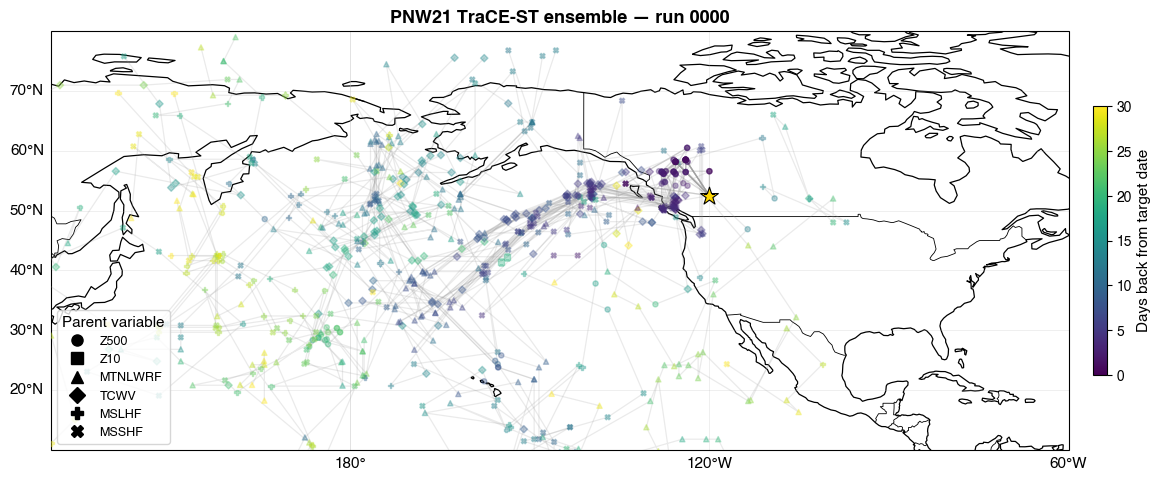

In [14]:
run_id = 0 # change this

params_sel = load_run_params(run_id)
summary_sel = load_run_summary(run_id)
results_sel = load_run_results(run_id)

print("Loaded run:", run_id)
print("n_requested:", summary_sel["n_requested"])
print("n_success:", summary_sel["n_success"])
print("n_failed:", summary_sel["n_failed"])

fig, ax = plot_trace_st_spaghetti(
    results_sel,
    full_data_run,
    timeres_hours=1,
    extent=(120, -50, 10, 80),
    title=f"PNW21 TraCE-ST ensemble — run {int(params_sel['run_id']):04d}",
    cmap_name="viridis",
    alpha_line=0.20,
    alpha_dot=0.35,
    linewidth=0.9,
    markersize=14,
    event_lon=240.0,
    event_lat=52.5,
)
plt.show()

In [16]:
# =========================================================
# Pool all successful ensemble members from kept runs,
# keeping the run-specific box_size attached to each member
# =========================================================
pooled_members = []

for run_id in df_keep.run_id.values:
    params_sel = load_run_params(run_id)
    summary_sel = load_run_summary(run_id)
    results_sel = load_run_results(run_id)

    box_size_sel = float(params_sel["box_size"])

    successful_sel = [r for r in results_sel if r.get("success", True)]

    for r in successful_sel:
        pooled_members.append({
            "run_id": int(run_id),
            "box_size": box_size_sel,
            "centers": np.asarray(r["centers"], dtype=float),
            "parents": np.asarray(r["parents"], dtype=int),
        })

    print(
        f"run {int(run_id):04d} | "
        f"box_size={box_size_sel} | "
        f"success {summary_sel['n_success']}/{summary_sel['n_requested']}"
    )

print("\nTotal kept runs:", len(df_keep))
print("Total pooled successful members:", len(pooled_members))

run 0000 | box_size=30.0 | success 30/30
run 0001 | box_size=30.0 | success 30/30
run 0002 | box_size=35.0 | success 30/30
run 0005 | box_size=35.0 | success 30/30
run 0006 | box_size=40.0 | success 30/30
run 0007 | box_size=35.0 | success 30/30
run 0008 | box_size=30.0 | success 30/30
run 0009 | box_size=40.0 | success 30/30
run 0010 | box_size=30.0 | success 30/30
run 0011 | box_size=30.0 | success 30/30
run 0012 | box_size=30.0 | success 30/30
run 0013 | box_size=30.0 | success 30/30
run 0014 | box_size=35.0 | success 30/30
run 0015 | box_size=30.0 | success 30/30
run 0016 | box_size=40.0 | success 30/30
run 0017 | box_size=40.0 | success 30/30
run 0019 | box_size=35.0 | success 30/30
run 0020 | box_size=30.0 | success 30/30
run 0021 | box_size=35.0 | success 30/30
run 0022 | box_size=30.0 | success 30/30
run 0023 | box_size=40.0 | success 30/30
run 0024 | box_size=40.0 | success 30/30
run 0025 | box_size=30.0 | success 30/30
run 0026 | box_size=30.0 | success 30/30
run 0027 | box_s

In [17]:
def density_by_variable_for_time_window_boxes_variable_boxsize(
    pooled_members,
    *,
    full_data_run,
    t_start,   # inclusive
    t_end,     # exclusive
):
    """
    Compute density maps using the run-specific box_size for each pooled member.

    pooled_members: list of dicts with keys
        - centers
        - parents
        - box_size
    """
    lat_name = "lat" if "lat" in full_data_run.coords else "latitude"
    lon_name = "lon" if "lon" in full_data_run.coords else "longitude"

    lats = np.asarray(full_data_run[lat_name].values, dtype=float)
    lons = np.asarray(full_data_run[lon_name].values, dtype=float)  # assume 0..360
    var_names = [str(v) for v in full_data_run["var"].values]
    n_vars = len(var_names)

    counts = np.zeros((n_vars, len(lats), len(lons)), dtype=np.float64)

    for member in pooled_members:
        centers = np.asarray(member["centers"], dtype=float)
        parents = np.asarray(member["parents"], dtype=int)
        half = 0.5 * float(member["box_size"])

        nT = min(len(centers), len(parents))
        a = max(0, int(t_start))
        b = min(nT, int(t_end))
        if b <= a:
            continue

        for (lat_c, lon_c), v in zip(centers[a:b], parents[a:b]):
            k = int(v) - 1
            if not (0 <= k < n_vars):
                continue

            lat_c = float(lat_c)
            lon_c = float(lon_c) % 360.0

            lat_lo, lat_hi = lat_c - half, lat_c + half
            ilats = np.where((lats >= lat_lo) & (lats <= lat_hi))[0]
            if ilats.size == 0:
                continue

            lon_lo = (lon_c - half) % 360.0
            lon_hi = (lon_c + half) % 360.0
            if lon_lo <= lon_hi:
                ilons = np.where((lons >= lon_lo) & (lons <= lon_hi))[0]
            else:
                ilons = np.where((lons >= lon_lo) | (lons <= lon_hi))[0]

            if ilons.size == 0:
                continue

            counts[k][np.ix_(ilats, ilons)] += 1.0

    return counts, var_names, lats, lons

In [18]:
def plot_pooled_density_windows_by_var_rows_variable_boxsize(
    pooled_members,
    *,
    full_data_run,
    windows=((0, 10), (10, 20), (20, 30)),
    row_labels=("1-10 d", "11-20 d", "21-30 d"),
    extent=(120, -50, 10, 80),
    central_longitude=180,
    row_vmax=(None, None, None),
    row_vmin=(0, 0, 0),
    normalize_rows=False,
    cmap="hot_r",
    figsize_per_panel=3.25,
    title=None,
    cbar_labels=None,
    event_lon=None,
    event_lat=None,
    event_marker="*",
    event_color="gold",
    event_size=65,
):
    n_rows = len(windows)
    if len(row_labels) != n_rows:
        raise ValueError("row_labels must have same length as windows")
    if len(row_vmax) != n_rows:
        raise ValueError("row_vmax must have same length as windows")
    if len(row_vmin) != n_rows:
        raise ValueError("row_vmin must have same length as windows")

    counts_rows = []
    var_names = None
    lats = None
    lons = None

    for (a, b) in windows:
        counts, var_names, lats, lons = density_by_variable_for_time_window_boxes_variable_boxsize(
            pooled_members,
            full_data_run=full_data_run,
            t_start=a,
            t_end=b,
        )
        counts_rows.append(counts)

    if normalize_rows:
        counts_rows_norm = []
        for counts in counts_rows:
            counts2 = counts.astype(float).copy()
            total = counts2.sum()
            if total > 0:
                counts2 /= total
            counts_rows_norm.append(counts2)
        counts_rows = counts_rows_norm

    lon_pm = ((lons + 180) % 360) - 180
    order = np.argsort(lon_pm)
    lon_plot = lon_pm[order]

    n_vars = len(var_names)
    fig_w = max(14, figsize_per_panel * n_vars)
    fig_h = 3.15 * n_rows + 1.1
    fig, axes = plt.subplots(
        n_rows,
        n_vars,
        figsize=(fig_w, fig_h),
        subplot_kw=dict(projection=ccrs.PlateCarree(central_longitude=central_longitude)),
        squeeze=False,
        constrained_layout=False,
    )

    if cbar_labels is None:
        if normalize_rows:
            cbar_labels = ["Fraction of pooled density"] * n_rows
        else:
            cbar_labels = ["Box-cover count across pooled members"] * n_rows

    row_mappables = []

    for irow in range(n_rows):
        counts = counts_rows[irow]
        this_vmax = row_vmax[irow]
        this_vmin = row_vmin[irow]

        if this_vmax is None:
            vals = counts[np.isfinite(counts)]
            vals = vals[vals > 0]
            this_vmax = np.percentile(vals, 99.5) if vals.size else 1.0

        row_mesh = None

        for icol in range(n_vars):
            ax = axes[irow, icol]

            ax.set_facecolor("white")
            ax.add_feature(cfeature.LAND, facecolor="white", edgecolor="none", zorder=0)
            ax.add_feature(cfeature.OCEAN, facecolor="white", edgecolor="none", zorder=0)
            ax.add_feature(cfeature.COASTLINE, linewidth=0.8, zorder=3)
            ax.add_feature(cfeature.BORDERS, linewidth=0.4, zorder=3)

            gl = ax.gridlines(draw_labels=False, linewidth=0.35, alpha=0.35, linestyle="--")
            gl.top_labels = False
            gl.right_labels = False

            ax.set_extent(
                extent,
                crs=ccrs.PlateCarree(central_longitude=central_longitude)
            )

            H = counts[icol][:, order]
            mesh = ax.pcolormesh(
                lon_plot,
                lats,
                H,
                transform=ccrs.PlateCarree(),
                shading="auto",
                vmin=this_vmin,
                vmax=this_vmax,
                cmap=cmap,
                zorder=1,
            )
            row_mesh = mesh

            if irow == 0:
                ax.set_title(var_names[icol], fontsize=12, fontweight="bold", pad=6)

            if icol == 0:
                ax.text(
                    -0.11, 0.5, row_labels[irow],
                    transform=ax.transAxes,
                    rotation=90,
                    va="center",
                    ha="center",
                    fontsize=12,
                    fontweight="bold",
                )

            if event_lon is not None and event_lat is not None:
                ax.scatter(
                    ((event_lon + 180) % 360) - 180,
                    event_lat,
                    marker=event_marker,
                    s=event_size,
                    color=event_color,
                    edgecolor="k",
                    linewidth=0.6,
                    transform=ccrs.PlateCarree(),
                    zorder=5,
                )

        row_mappables.append(row_mesh)

    fig.subplots_adjust(
        left=0.055,
        right=0.97,
        top=0.90,
        bottom=0.14,
        wspace=0.06,
        hspace=0.12,
    )

    for irow in range(n_rows):
        left = 0.32
        width = 0.40
        height = 0.016
        y_positions = [0.665, 0.395, 0.125]
        y = y_positions[irow] if n_rows == 3 else 0.12 + (n_rows - 1 - irow) * (0.70 / max(1, n_rows - 1))

        cax = fig.add_axes([left, y, width, height])
        cb = fig.colorbar(row_mappables[irow], cax=cax, orientation="horizontal")
        cb.set_label(cbar_labels[irow], fontsize=10)
        cb.ax.tick_params(labelsize=9)

    if title is not None:
        fig.suptitle(title, fontsize=15, fontweight="bold", y=0.965)

    return fig, axes

In [20]:
def plot_window_mean_fields_by_var(
    full_data_run,
    *,
    date_end,
    windows=((0, 10), (10, 20), (20, 30)),
    row_labels=("1-10 d", "11-20 d", "21-30 d"),
    timeres_days=1.0,
    extent=(120, -50, 10, 80),
    central_longitude=180,
    cmap="RdBu_r",
    robust_percentile=99.0,
    symmetric=True,
    figsize_per_panel=3.25,
    title=None,
    cbar_label="Mean anomaly",
):
    """
    Plot mean fields for each variable and time window.

    Parameters
    ----------
    full_data_run : xr.DataArray
        Expected dims include time, var, lat/lon.
    date_end : str or datetime-like
        Target date corresponding to trajectory step 0.
    windows : tuple of (start, end)
        Window indices in the same convention as your trajectory plots:
        (0,10), (10,20), (20,30), etc.
        Each window is [start, end), inclusive-exclusive in step index.
    timeres_days : float
        Time resolution in days between steps.
    symmetric : bool
        If True, use symmetric color limits around zero for each variable.
    robust_percentile : float
        Percentile used to define variable-specific color limits.
    """

    # ----------------------------
    # Infer coordinate names
    # ----------------------------
    time_name = "time"
    lat_name = "lat" if "lat" in full_data_run.coords else "latitude"
    lon_name = "lon" if "lon" in full_data_run.coords else "longitude"

    var_names = [str(v) for v in full_data_run["var"].values]
    n_vars = len(var_names)
    n_rows = len(windows)

    if len(row_labels) != n_rows:
        raise ValueError("row_labels must have same length as windows")

    # ----------------------------
    # Find target time index
    # ----------------------------
    time_vals = pd.to_datetime(full_data_run[time_name].values)
    target_time = pd.Timestamp(date_end)

    # nearest time index
    idx_end = int(np.argmin(np.abs(time_vals - target_time)))
    matched_time = pd.Timestamp(time_vals[idx_end])

    print(f"Requested date_end: {target_time}")
    print(f"Matched time in full_data_run: {matched_time}")

    # ----------------------------
    # Precompute mean fields
    # ----------------------------
    lon_vals = np.asarray(full_data_run[lon_name].values, dtype=float)
    lon_pm = ((lon_vals + 180) % 360) - 180
    lon_order = np.argsort(lon_pm)
    lon_plot = lon_pm[lon_order]

    mean_fields = {}   # (irow, icol) -> 2D array
    var_limits = {}    # var_name -> (vmin, vmax)

    for icol, vname in enumerate(var_names):
        fields_this_var = []

        for irow, (a, b) in enumerate(windows):
            # trajectory step s corresponds to date_end - s * timeres_days
            step_offsets = np.arange(a, b, dtype=int)
            time_indices = idx_end - np.round(step_offsets * timeres_days).astype(int)

            valid = (time_indices >= 0) & (time_indices < full_data_run.sizes[time_name])
            time_indices = time_indices[valid]

            if len(time_indices) == 0:
                arr2d = np.full(
                    (full_data_run.sizes[lat_name], full_data_run.sizes[lon_name]),
                    np.nan,
                    dtype=float,
                )
            else:
                da_mean = (
                    full_data_run
                    .sel(var=vname)
                    .isel({time_name: time_indices})
                    .mean(time_name)
                )
                arr2d = np.asarray(da_mean.values, dtype=float)

            arr2d = arr2d[:, lon_order]
            mean_fields[(irow, icol)] = arr2d
            fields_this_var.append(arr2d)

        # variable-specific color limits across all rows
        vals = np.concatenate([f[np.isfinite(f)] for f in fields_this_var if np.isfinite(f).any()])
        if len(vals) == 0:
            vmin, vmax = -1.0, 1.0
        else:
            if symmetric:
                vmax = np.percentile(np.abs(vals), robust_percentile)
                vmin = -vmax
            else:
                vmin = np.percentile(vals, 100 - robust_percentile)
                vmax = np.percentile(vals, robust_percentile)
                if vmin == vmax:
                    vmax = vmin + 1e-6

        var_limits[vname] = (vmin, vmax)

    # ----------------------------
    # Plot
    # ----------------------------
    fig_w = max(14, figsize_per_panel * n_vars)
    fig_h = 3.15 * n_rows + 1.5

    fig, axes = plt.subplots(
        n_rows,
        n_vars,
        figsize=(fig_w, fig_h),
        subplot_kw=dict(
            projection=ccrs.PlateCarree(central_longitude=central_longitude)
        ),
        squeeze=False,
        constrained_layout=False,
    )

    proj_data = ccrs.PlateCarree()
    col_mappables = [None] * n_vars

    for irow in range(n_rows):
        for icol, vname in enumerate(var_names):
            ax = axes[irow, icol]
            arr2d = mean_fields[(irow, icol)]
            vmin, vmax = var_limits[vname]

            ax.set_facecolor("white")
            ax.add_feature(cfeature.LAND, facecolor="white", edgecolor="none", zorder=0)
            ax.add_feature(cfeature.OCEAN, facecolor="white", edgecolor="none", zorder=0)
            ax.add_feature(cfeature.COASTLINE, linewidth=0.8, zorder=3)
            ax.add_feature(cfeature.BORDERS, linewidth=0.4, zorder=3)

            gl = ax.gridlines(draw_labels=False, linewidth=0.35, alpha=0.35, linestyle="--")
            gl.top_labels = False
            gl.right_labels = False

            ax.set_extent(
                extent,
                crs=ccrs.PlateCarree(central_longitude=central_longitude)
            )

            mesh = ax.pcolormesh(
                lon_plot,
                np.asarray(full_data_run[lat_name].values, dtype=float),
                arr2d,
                transform=proj_data,
                shading="auto",
                cmap=cmap,
                vmin=vmin,
                vmax=vmax,
                zorder=1,
            )

            if irow == 0:
                ax.set_title(vname, fontsize=12, fontweight="bold", pad=6)

            if icol == 0:
                ax.text(
                    -0.11, 0.5, row_labels[irow],
                    transform=ax.transAxes,
                    rotation=90,
                    va="center",
                    ha="center",
                    fontsize=12,
                    fontweight="bold",
                )

            col_mappables[icol] = mesh

    # ----------------------------
    # Layout
    # ----------------------------
    fig.subplots_adjust(
        left=0.055,
        right=0.985,
        top=0.90,
        bottom=0.15,
        wspace=0.06,
        hspace=0.12,
    )

    # ----------------------------
    # One colorbar per column
    # ----------------------------
    fig.canvas.draw()

    for icol in range(n_vars):
        ax_bottom = axes[-1, icol]
        pos = ax_bottom.get_position()

        cax = fig.add_axes([
            pos.x0,
            pos.y0 - 0.055,
            pos.width,
            0.018
        ])
        cb = fig.colorbar(col_mappables[icol], cax=cax, orientation="horizontal")
        cb.set_label(cbar_label, fontsize=9)
        cb.ax.tick_params(labelsize=8)

    if title is None:
        title = f"Mean fields by variable and window (ending {matched_time.date()})"

    fig.suptitle(title, fontsize=15, fontweight="bold", y=0.965)

    return fig, axes

# Fig4

In [22]:
# =========================================================
# Labels
# =========================================================
VAR_LABELS_PNW = {
    "Z500": "Z500",
    "Z10": "Z10",
    "MTNLWRF": "OLR",
    "MVIMD": "VIMD",
    "TCWV": "TCWV",
    "MSLHF": "LHF",
    "MSSHF": "SHF",
}


# =========================================================
# Basic helpers
# =========================================================
def lon0360_to_m180_180(lon):
    lon = np.asarray(lon, dtype=float) % 360.0
    return ((lon + 180.0) % 360.0) - 180.0


def _infer_lat_lon_names(full_data_run):
    lat_name = "lat" if "lat" in full_data_run.coords else "latitude"
    lon_name = "lon" if "lon" in full_data_run.coords else "longitude"
    return lat_name, lon_name


def _style_geo_ax(ax, extent, central_longitude=180, add_grid=True):
    proj = ccrs.PlateCarree(central_longitude=central_longitude)
    ax.set_extent(extent, crs=proj)
    ax.set_facecolor("white")
    ax.add_feature(cfeature.LAND, facecolor="white", edgecolor="none", zorder=0)
    ax.add_feature(cfeature.OCEAN, facecolor="white", edgecolor="none", zorder=0)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.8, zorder=3)
    ax.add_feature(cfeature.BORDERS, linewidth=0.4, zorder=3)

    if add_grid:
        gl = ax.gridlines(draw_labels=False, linewidth=0.35, alpha=0.35, linestyle="--")
        gl.top_labels = False
        gl.right_labels = False


# =========================================================
# Density helpers
# =========================================================
def density_by_variable_for_time_window_boxes_variable_boxsize(
    pooled_members,
    *,
    full_data_run,
    t_start,
    t_end,
):
    lat_name, lon_name = _infer_lat_lon_names(full_data_run)

    lats = np.asarray(full_data_run[lat_name].values, dtype=float)
    lons = np.asarray(full_data_run[lon_name].values, dtype=float)
    var_names = [str(v) for v in full_data_run["var"].values]
    n_vars = len(var_names)

    counts = np.zeros((n_vars, len(lats), len(lons)), dtype=np.float64)

    for member in pooled_members:
        centers = np.asarray(member["centers"], dtype=float)
        parents = np.asarray(member["parents"], dtype=int)
        half = 0.5 * float(member["box_size"])

        nT = min(len(centers), len(parents))
        a = max(0, int(t_start))
        b = min(nT, int(t_end))
        if b <= a:
            continue

        for (lat_c, lon_c), v in zip(centers[a:b], parents[a:b]):
            k = int(v) - 1
            if not (0 <= k < n_vars):
                continue

            lat_c = float(lat_c)
            lon_c = float(lon_c) % 360.0

            lat_lo, lat_hi = lat_c - half, lat_c + half
            ilats = np.where((lats >= lat_lo) & (lats <= lat_hi))[0]
            if ilats.size == 0:
                continue

            lon_lo = (lon_c - half) % 360.0
            lon_hi = (lon_c + half) % 360.0
            if lon_lo <= lon_hi:
                ilons = np.where((lons >= lon_lo) & (lons <= lon_hi))[0]
            else:
                ilons = np.where((lons >= lon_lo) | (lons <= lon_hi))[0]
            if ilons.size == 0:
                continue

            counts[k][np.ix_(ilats, ilons)] += 1.0

    return counts, var_names, lats, lons


def total_density_all_steps_variable_boxsize(
    pooled_members,
    *,
    full_data_run,
):
    lat_name, lon_name = _infer_lat_lon_names(full_data_run)

    lats = np.asarray(full_data_run[lat_name].values, dtype=float)
    lons = np.asarray(full_data_run[lon_name].values, dtype=float)
    counts = np.zeros((len(lats), len(lons)), dtype=np.float64)

    for member in pooled_members:
        centers = np.asarray(member["centers"], dtype=float)
        half = 0.5 * float(member["box_size"])

        for (lat_c, lon_c) in centers:
            lat_c = float(lat_c)
            lon_c = float(lon_c) % 360.0

            lat_lo, lat_hi = lat_c - half, lat_c + half
            ilats = np.where((lats >= lat_lo) & (lats <= lat_hi))[0]
            if ilats.size == 0:
                continue

            lon_lo = (lon_c - half) % 360.0
            lon_hi = (lon_c + half) % 360.0
            if lon_lo <= lon_hi:
                ilons = np.where((lons >= lon_lo) & (lons <= lon_hi))[0]
            else:
                ilons = np.where((lons >= lon_lo) | (lons <= lon_hi))[0]
            if ilons.size == 0:
                continue

            counts[np.ix_(ilats, ilons)] += 1.0

    return counts, lats, lons


# =========================================================
# Variable relevance by run
# =========================================================
def compute_variable_importance_by_run(
    pooled_members,
    *,
    full_data_run,
    windows=((0, 10), (10, 20), (20, 30)),
    window_labels=("Days 1–10", "Days 11–20", "Days 21–30"),
):
    var_names = [str(v) for v in full_data_run["var"].values]

    by_run = {}
    for member in pooled_members:
        by_run.setdefault(int(member["run_id"]), []).append(member)

    out = {label: [] for label in window_labels}

    for run_id, members in by_run.items():
        for (a, b), label in zip(windows, window_labels):
            counts, _, _, _ = density_by_variable_for_time_window_boxes_variable_boxsize(
                members,
                full_data_run=full_data_run,
                t_start=a,
                t_end=b,
            )
            integrated = counts.sum(axis=(1, 2)).astype(float)
            total = integrated.sum()
            norm = integrated / total if total > 0 else np.full(len(var_names), np.nan)
            out[label].append(norm)

    for label in window_labels:
        out[label] = np.asarray(out[label], dtype=float)

    return out, var_names


# =========================================================
# Panel A
# =========================================================
def draw_panel_representative_trajectories(
    ax,
    pooled_members,
    full_data_run,
    *,
    n_samples=100,
    seed=42,
    timeres_hours=24.0,
    extent=(120, -50, 10, 80),
    central_longitude=180,
    cmap_name="cool_r",
    alpha_line=0.18,
    alpha_dot=0.40,
    linewidth=0.8,
    markersize=18,   # increased again
    event_lon=None,
    event_lat=None,
):
    rng = np.random.default_rng(seed)
    n_samples = min(int(n_samples), len(pooled_members))
    sample_idx = rng.choice(len(pooled_members), size=n_samples, replace=False)
    sampled = [pooled_members[i] for i in sample_idx]

    var_names = [str(v) for v in full_data_run["var"].values]
    marker_cycle = ["o", "s", "^", "D", "P", "X", "v", "<", ">", "*"]
    marker_map = {name: marker_cycle[i % len(marker_cycle)] for i, name in enumerate(var_names)}

    max_steps = max(len(np.asarray(m["centers"])) for m in sampled)
    days_back_all = np.arange(max_steps) * (float(timeres_hours) / 24.0)

    cmap = plt.get_cmap(cmap_name)
    norm = mpl.colors.Normalize(
        vmin=float(np.nanmin(days_back_all)),
        vmax=float(np.nanmax(days_back_all)),
    )

    geo = ccrs.PlateCarree()
    _style_geo_ax(ax, extent, central_longitude=central_longitude, add_grid=False)

    for member in sampled:
        centers = np.asarray(member["centers"], dtype=float)
        parents = np.asarray(member["parents"], dtype=int)

        if len(centers) == 0:
            continue

        lats = centers[:, 0]
        lons = centers[:, 1] % 360.0
        steps = np.arange(len(lats))
        days_back = steps * (float(timeres_hours) / 24.0)

        ax.plot(
            lons,
            lats,
            "-",
            color="k",
            linewidth=linewidth,
            alpha=alpha_line,
            transform=geo,
            zorder=2,
        )

        p0 = np.clip(parents - 1, 0, len(var_names) - 1)
        parent_labels = np.array([var_names[i] for i in p0])

        for vname in var_names:
            mask = parent_labels == vname
            if not np.any(mask):
                continue

            idx = np.where(mask)[0]#[::2]
            ax.scatter(
                lons[idx],
                lats[idx],
                c=days_back[idx],
                cmap=cmap,
                norm=norm,
                marker=marker_map[vname],
                s=markersize,
                alpha=alpha_dot,
                edgecolor="none",
                transform=geo,
                zorder=3,
            )

    if event_lon is not None and event_lat is not None:
        ax.scatter(
            event_lon,
            event_lat,
            marker="*",
            s=130,
            color="gold",
            edgecolor="k",
            linewidth=0.7,
            transform=geo,
            zorder=5,
        )

    return norm, cmap, marker_map


# =========================================================
# Panel B
# =========================================================
def draw_panel_total_density(
    ax,
    pooled_members,
    full_data_run,
    *,
    extent=(120, -50, 10, 80),
    central_longitude=180,
    cmap="hot_r",
    vmax_percentile=99.5,
    event_lon=None,
    event_lat=None,
):
    counts_total, lats, lons = total_density_all_steps_variable_boxsize(
        pooled_members,
        full_data_run=full_data_run,
    )

    lon_pm = ((lons + 180) % 360) - 180
    order = np.argsort(lon_pm)
    lon_plot = lon_pm[order]
    H = counts_total[:, order]

    geo = ccrs.PlateCarree()
    _style_geo_ax(ax, extent, central_longitude=central_longitude, add_grid=True)

    vals = H[np.isfinite(H)]
    vals = vals[vals > 0]
    vmax = np.percentile(vals, vmax_percentile) if vals.size else 1.0

    mesh = ax.pcolormesh(
        lon_plot,
        lats,
        H,
        transform=geo,
        shading="auto",
        cmap=cmap,
        vmin=0,
        vmax=vmax,
        alpha=0.85,
        zorder=1,
        rasterized=True
    )

    if event_lon is not None and event_lat is not None:
        ax.scatter(
            ((event_lon + 180) % 360) - 180,
            event_lat,
            marker="*",
            s=130,
            color="gold",
            edgecolor="k",
            linewidth=0.7,
            transform=geo,
            zorder=5,
        )

    return mesh


# =========================================================
# Panel C
# =========================================================
def draw_panel_variable_importance(
    ax,
    pooled_members,
    full_data_run,
    *,
    windows=((0, 10), (10, 20), (20, 30)),
    window_labels=("Days 1–10", "Days 11–20", "Days 21–30"),
    p_lo=10,
    p_hi=90,
):
    imp_by_run, var_names = compute_variable_importance_by_run(
        pooled_members,
        full_data_run=full_data_run,
        windows=windows,
        window_labels=window_labels,
    )

    x = np.arange(len(var_names))
    width = 0.24

    # colors chosen to resemble cool_r progression
    colors = ["#b12ad4", "#6a7fdc", "#63d4de"]  # purple, blue, cyan

    for i, label in enumerate(window_labels):
        arr = imp_by_run[label]
        med = np.nanmedian(arr, axis=0)
        lo = np.nanpercentile(arr, p_lo, axis=0)
        hi = np.nanpercentile(arr, p_hi, axis=0)
        yerr = np.vstack([med - lo, hi - med])

        ax.bar(
            x + (i - 1) * width,
            med,
            width=width,
            color=colors[i],
            label=label,
            alpha=0.95,
            yerr=yerr,
            ecolor="k",
            capsize=3,
            linewidth=0.8,
        )

    ax.set_xticks(x)
    ax.set_xticklabels([VAR_LABELS_PNW.get(v, v) for v in var_names], rotation=35, ha="right")
    ax.set_ylabel("Normalized integrated density",fontsize=11)
    ax.grid(True, axis="y", alpha=0.25)
    ax.legend(frameon=True, fontsize=9)
    ax.set_ylim(bottom=0)

def draw_panel_variable_importance_boxplots(
    ax,
    pooled_members,
    full_data_run,
    *,
    windows=((0, 10), (10, 20), (20, 30)),
    window_labels=("Days 1–10", "Days 11–20", "Days 21–30"),
):
    imp_by_run, var_names = compute_variable_importance_by_run(
        pooled_members,
        full_data_run=full_data_run,
        windows=windows,
        window_labels=window_labels,
    )

    x = np.arange(len(var_names), dtype=float)
    offsets = np.array([-0.26, 0.0, 0.26])
    width = 0.22

    colors = ["#b12ad4", "#6a7fdc", "#63d4de"]  # purple, blue, cyan

    legend_handles = []

    for i, label in enumerate(window_labels):
        arr = np.asarray(imp_by_run[label], dtype=float)   # shape: (n_runs, n_vars)

        data_i = []
        pos_i = []
        for j in range(len(var_names)):
            vals = arr[:, j]
            vals = vals[np.isfinite(vals)]
            data_i.append(vals)
            pos_i.append(x[j] + offsets[i])

        bp = ax.boxplot(
            data_i,
            positions=pos_i,
            widths=width,
            patch_artist=True,
            showfliers=True,
            medianprops=dict(color="0.15", linewidth=1.4),
            whiskerprops=dict(color="0.2", linewidth=1.0),
            capprops=dict(color="0.2", linewidth=1.0),
            boxprops=dict(linewidth=1.0, color="0.2"),
        )

        for patch in bp["boxes"]:
            patch.set_facecolor(colors[i])
            patch.set_edgecolor(colors[i])
            patch.set_alpha(0.38)

        legend_handles.append(
            Line2D([0], [0], color=colors[i], lw=6, alpha=0.6, label=label)
        )

    ax.set_xticks(x)
    ax.set_xticklabels([VAR_LABELS_PNW.get(v, v) for v in var_names], rotation=35, ha="right")
    ax.set_ylabel("Normalized integrated density", fontsize=11)
    ax.grid(True, axis="y", alpha=0.25)
    ax.legend(handles=legend_handles, frameon=True, fontsize=9)
    ax.set_ylim(bottom=0)


# =========================================================
# Panel D
# =========================================================
def draw_panel_density_windows_by_var(
    fig,
    gs_sub,
    pooled_members,
    full_data_run,
    *,
    windows=((0, 10), (10, 20), (20, 30)),
    row_labels=("1–10 d", "11–20 d", "21–30 d"),
    extent=(120, -50, 10, 80),
    central_longitude=180,
    row_vmax=(None, None, None),
    row_vmin=(0, 0, 0),
    normalize_rows=True,
    cmap="hot_r",
    event_lon=None,
    event_lat=None,
):
    var_names = [str(v) for v in full_data_run["var"].values]
    n_rows = len(windows)
    n_vars = len(var_names)

    counts_rows = []
    lats = None
    lons = None

    for (a, b) in windows:
        counts, _, lats, lons = density_by_variable_for_time_window_boxes_variable_boxsize(
            pooled_members,
            full_data_run=full_data_run,
            t_start=a,
            t_end=b,
        )
        counts_rows.append(counts)

    if normalize_rows:
        counts_rows_norm = []
        for counts in counts_rows:
            counts2 = counts.astype(float).copy()
            total = counts2.sum()
            if total > 0:
                counts2 /= total
            counts_rows_norm.append(counts2)
        counts_rows = counts_rows_norm

    lon_pm = ((lons + 180) % 360) - 180
    order = np.argsort(lon_pm)
    lon_plot = lon_pm[order]

    geo = ccrs.PlateCarree()
    proj = ccrs.PlateCarree(central_longitude=central_longitude)

    axes = np.empty((n_rows, n_vars), dtype=object)
    row_mappables = []

    for irow in range(n_rows):
        counts = counts_rows[irow]
        this_vmax = row_vmax[irow]
        this_vmin = row_vmin[irow]

        if this_vmax is None:
            vals = counts[np.isfinite(counts)]
            vals = vals[vals > 0]
            this_vmax = np.percentile(vals, 99.5) if vals.size else 1.0

        row_mesh = None

        for icol in range(n_vars):
            ax = fig.add_subplot(gs_sub[irow, icol], projection=proj)
            axes[irow, icol] = ax

            _style_geo_ax(ax, extent, central_longitude=central_longitude, add_grid=True)

            H = counts[icol][:, order]
            mesh = ax.pcolormesh(
                lon_plot,
                lats,
                H,
                transform=geo,
                shading="auto",
                vmin=this_vmin,
                vmax=this_vmax,
                cmap=cmap,
                zorder=1,
                rasterized=True
            )
            row_mesh = mesh

            if irow == 0:
                ax.set_title(VAR_LABELS_PNW.get(var_names[icol], var_names[icol]),
                             fontsize=11, fontweight="bold", pad=5)

            if icol == 0:
                ax.text(
                    -0.12, 0.5, row_labels[irow],
                    transform=ax.transAxes,
                    rotation=90,
                    va="center",
                    ha="center",
                    fontsize=11,
                    fontweight="bold",
                )

            if event_lon is not None and event_lat is not None:
                ax.scatter(
                    ((event_lon + 180) % 360) - 180,
                    event_lat,
                    marker="*",
                    s=38,
                    color="gold",
                    edgecolor="k",
                    linewidth=0.4,
                    transform=geo,
                    zorder=5,
                )

        row_mappables.append(row_mesh)

    return axes, row_mappables


# =========================================================
# Main figure
# =========================================================
def plot_trace_st_pnw_main_figure(
    pooled_members,
    full_data_run,
    *,
    n_rep_traj=100,
    seed=42,
    windows=((0, 10), (10, 20), (20, 30)),
    row_labels=("1–10 d", "11–20 d", "21–30 d"),
    extent=(120, -50, 10, 80),
    central_longitude=180,
    event_lon=None,
    event_lat=None,
    p_lo=10,
    p_hi=90,
):
    proj = ccrs.PlateCarree(central_longitude=central_longitude)

    fig = plt.figure(figsize=(16, 11))
    outer = gridspec.GridSpec(
        2, 1,
        figure=fig,
        height_ratios=[0.90, 1.60],
        hspace=0.33,
    )

    # -------------------------
    # Top row with shorter C
    # -------------------------
    gs_top = gridspec.GridSpecFromSubplotSpec(
        2, 3,
        subplot_spec=outer[0],
        height_ratios=[0.78, 0.22],
        width_ratios=[1., 1., 1],
        hspace=0.12,
        wspace=0.18,
    )

    axA = fig.add_subplot(gs_top[0, 0], projection=proj)
    axB = fig.add_subplot(gs_top[0, 1], projection=proj)
    axC = fig.add_subplot(gs_top[:, 2])

    # Placeholder axes for colorbars under A and B
    axA_cb = fig.add_subplot(gs_top[1, 0])
    axB_cb = fig.add_subplot(gs_top[1, 1])
    axA_cb.axis("off")
    axB_cb.axis("off")

    # A
    lag_norm, lag_cmap, marker_map = draw_panel_representative_trajectories(
        axA,
        pooled_members,
        full_data_run,
        n_samples=n_rep_traj,
        seed=seed,
        timeres_hours=24.0,
        extent=extent,
        central_longitude=central_longitude,
        cmap_name="cool_r",
        alpha_line=0.18,
        alpha_dot=0.4,
        linewidth=0.8,
        markersize=25,
        event_lon=event_lon,
        event_lat=event_lat,
    )
    axA.set_title("A. Representative trajectories", loc="left", fontsize=14, fontweight="bold")

    # B
    mesh_total = draw_panel_total_density(
        axB,
        pooled_members,
        full_data_run,
        extent=extent,
        central_longitude=central_longitude,
        cmap="hot_r",
        vmax_percentile=99.5,
        event_lon=event_lon,
        event_lat=event_lat,
    )
    axB.set_title("B. Density of trajectories", loc="left", fontsize=14, fontweight="bold")

    # C
    draw_panel_variable_importance_boxplots(
        axC,
        pooled_members,
        full_data_run,
        windows=windows,
        window_labels=("Days 1–10", "Days 11–20", "Days 21–30"),
    )
    axC.set_title("C. Variable relevance over time", loc="left", fontsize=14, fontweight="bold")

    # -------------------------
    # Bottom block
    # -------------------------
    gs_bottom = gridspec.GridSpecFromSubplotSpec(
        3, len(full_data_run["var"]),
        subplot_spec=outer[1],
        wspace=0.05,
        hspace=0.50,   # increased again
    )

    axesD, row_mappables = draw_panel_density_windows_by_var(
        fig,
        gs_bottom,
        pooled_members,
        full_data_run,
        windows=windows,
        row_labels=row_labels,
        extent=extent,
        central_longitude=central_longitude,
        row_vmax=(2.5e4, 0.5e4, 0.3e4),                        
        row_vmin=(0, 0, 0),
        normalize_rows=False,
        cmap="hot_r",
        event_lon=event_lon,
        event_lat=event_lat,
    )

    # D title (manual position)
    fig.text(
        0.11, 0.57,
        "D. Variable-specific densities by window",
        ha="left",
        va="top",
        fontsize=14,
        fontweight="bold",
    )

    # =====================================================
    # MANUAL legend + colorbar positions
    # =====================================================

    var_names = [str(v) for v in full_data_run["var"].values]
    legend_handles = [
        Line2D([0], [0], marker=marker_map[v], linestyle="None",
               markerfacecolor="k", markeredgecolor="k",
               markersize=7, label=VAR_LABELS_PNW.get(v, v))
        for v in var_names
    ]
    legend_handles += [
        Line2D([0], [0], marker="*", color="gold", markeredgecolor="k",
               linestyle="None", markersize=10, label="Target point"),
    ]

    fig.legend(
        handles=legend_handles,
        loc="upper left",
        bbox_to_anchor=(0.135, 0.7),
        ncol=3,
        frameon=True,
        fontsize=10,
        title="Parent variable / markers",
        title_fontsize=11,
        columnspacing=1.5,
        handletextpad=0.6,
    )

    # A colorbar
    cax_lag = fig.add_axes([0.355, 0.72, 0.007, 0.15])
    sm_lag = mpl.cm.ScalarMappable(norm=lag_norm, cmap=lag_cmap)
    sm_lag.set_array([])
    cb_lag = fig.colorbar(sm_lag, cax=cax_lag, orientation="vertical")
    cb_lag.set_label("Days back from target", fontsize=12)
    cb_lag.ax.tick_params(labelsize=10)

    # B colorbar
    cax_den = fig.add_axes([0.435, 0.67, 0.15, 0.012])
    cb_den = fig.colorbar(mesh_total, cax=cax_den, orientation="horizontal")
    cb_den.set_label("Total density", fontsize=12)
    cb_den.ax.tick_params(labelsize=10)

    from matplotlib.ticker import ScalarFormatter
    
    # D row 1 colorbar
    cax_row1 = fig.add_axes([0.40, 0.417, 0.28, 0.01])
    cb_row1 = fig.colorbar(row_mappables[0], cax=cax_row1, orientation="horizontal")
    cb_row1.ax.tick_params(labelsize=10)
    
    fmt1 = ScalarFormatter(useMathText=True)
    fmt1.set_scientific(True)
    fmt1.set_powerlimits((0, 0))
    cb_row1.formatter = fmt1
    cb_row1.update_ticks()
    
    # D row 2 colorbar
    cax_row2 = fig.add_axes([0.40, 0.257, 0.28, 0.01])
    cb_row2 = fig.colorbar(row_mappables[1], cax=cax_row2, orientation="horizontal")
    cb_row2.ax.tick_params(labelsize=10)
    
    fmt2 = ScalarFormatter(useMathText=True)
    fmt2.set_scientific(True)
    fmt2.set_powerlimits((0, 0))
    cb_row2.formatter = fmt2
    cb_row2.update_ticks()
    
    # D row 3 colorbar
    cax_row3 = fig.add_axes([0.40, 0.0952, 0.28, 0.01])
    cb_row3 = fig.colorbar(row_mappables[2], cax=cax_row3, orientation="horizontal")
    cb_row3.set_label(f"Fraction of row density ({row_labels[2]})", fontsize=11)
    cb_row3.ax.tick_params(labelsize=10)
    
    fmt3 = ScalarFormatter(useMathText=True)
    fmt3.set_scientific(True)
    fmt3.set_powerlimits((0, 0))
    cb_row3.formatter = fmt3
    cb_row3.update_ticks()

    return fig

In [30]:
def _subset_lon_no_wrap(lons, arr2d, extent):
    """
    Return longitude subset without crossing the wrap seam.

    extent can be like (120, -50, 10, 80), meaning 120E to 310E.
    lons are expected in 0–360.
    """
    west, east, south, north = extent
    west360 = west % 360
    east360 = east % 360

    lons360 = np.asarray(lons, dtype=float) % 360

    if west360 <= east360:
        mask = (lons360 >= west360) & (lons360 <= east360)
    else:
        # Example: 120 to -50 means 120 to 310 in 0–360;
        # but this branch handles true wrap cases too.
        mask = (lons360 >= west360) | (lons360 <= east360)

    idx = np.where(mask)[0]
    idx = idx[np.argsort(lons360[idx])]

    return lons360[idx], arr2d[:, idx]

def plot_pnw_physical_patterns_stacked_mean_std(
    full_data_run,
    pooled_members,
    *,
    date_end,
    event_lon,
    event_lat,
    extent=(120, -50, 10, 80),
    central_longitude=180,
    timeres_days=1.0,

    mean_cmap="RdBu_r",
    mean_vmin=-1.5,
    mean_vmax=1.5,

    std_cmap="YlGnBu",
    std_vmin=0.0,
    std_vmax=1.5,

    # contour options
    contour_color_mode="by_window",  # "by_window" or "single"
    contour_color="k",              # used when contour_color_mode="single"
    contour_color_by_window=None,   # used when contour_color_mode="by_window"
    contour_linewidths=(0.8, 1.1, 1.5),
    contour_percentiles=(90, 95, 99),
    normalize_density_rows=True,
):

    lat_name, lon_name = _infer_lat_lon_names(full_data_run)

    if contour_color_by_window is None:
        contour_color_by_window = {
            (0, 10): "#c98245",   # 1–10 d
            (10, 20): "#5a284d",  # 11–20 d
            (20, 30): "#5f93d1",  # 21–30 d
        }

    def composite_field_for_window(var_name, a, b, mode="mean"):
        date_end_ts = pd.Timestamp(date_end)
        fields = []

        for step_idx in range(int(a), int(b)):
            target_time = date_end_ts - pd.Timedelta(days=float(step_idx) * float(timeres_days))
            da = full_data_run.sel(var=var_name).sel(time=target_time, method="nearest")
            fields.append(da)

        da_all = xr.concat(fields, dim="window_step")

        if mode == "mean":
            return da_all.mean("window_step")
        elif mode == "std":
            return da_all.std("window_step")
        elif mode == "rms":
            return np.sqrt((da_all ** 2).mean("window_step"))
        else:
            raise ValueError("mode must be 'mean', 'std', or 'rms'")

    def compute_window_density_dict(windows):
        density_dict = {}

        for (a, b) in windows:
            counts, var_names, lats, lons = density_by_variable_for_time_window_boxes_variable_boxsize(
                pooled_members,
                full_data_run=full_data_run,
                t_start=a,
                t_end=b,
            )

            if normalize_density_rows:
                total = counts.sum()
                if total > 0:
                    counts = counts / total

            density_dict[(a, b)] = {
                "counts": counts,
                "var_names": var_names,
                "lats": lats,
                "lons": lons,
            }

        return density_dict

    def get_contour_color_for_window(a, b):
        if contour_color_mode == "single":
            return contour_color
        elif contour_color_mode == "by_window":
            return contour_color_by_window.get((a, b), "0.2")
        else:
            raise ValueError("contour_color_mode must be 'single' or 'by_window'")

    def draw_block(fig, gs_block, field_mode, cmap, vmin, vmax, start_letter_idx):
        row1 = [
            ("Z500", (0, 10)),
            ("TCWV", (0, 10)),
        ]
        row2 = [
            ("Z500", (10, 20)),
            ("MTNLWRF", (10, 20)),
            ("MSSHF", (10, 20)),
            ("MSLHF", (10, 20)),
        ]
        row3 = [
            ("Z500", (20, 30)),
            ("MTNLWRF", (20, 30)),
            ("MSSHF", (20, 30)),
            ("MSLHF", (20, 30)),
        ]

        panel_rows = [row1, row2, row3]

        proj = ccrs.PlateCarree(central_longitude=central_longitude)
        axes = []
        mappable_for_cbar = None
        letter_idx = start_letter_idx

        for irow, row_spec in enumerate(panel_rows):
            for icol in range(4):
                if irow == 0 and icol >= 2:
                    continue

                var_name, (a, b) = row_spec[icol]
                ax = fig.add_subplot(gs_block[irow, icol], projection=proj)
                axes.append(ax)

                _style_geo_ax(ax, extent, central_longitude=central_longitude, add_grid=True)

                da_comp = composite_field_for_window(var_name, a, b, mode=field_mode)

                lons = np.asarray(da_comp[lon_name].values, dtype=float)
                lats = np.asarray(da_comp[lat_name].values, dtype=float)
                vals = np.asarray(da_comp.values, dtype=float)

                lon_plot, vals_plot = _subset_lon_no_wrap(lons, vals, extent)
                
                # --------------------------------------------------
                # Density contours + masking
                # --------------------------------------------------
                dens_info = density_dict[(a, b)]
                counts = dens_info["counts"]
                var_names = dens_info["var_names"]
                
                k = var_names.index(var_name)
                dens2d = counts[k]
                
                lons_d = np.asarray(dens_info["lons"], dtype=float)
                lats_d = np.asarray(dens_info["lats"], dtype=float)
                
                lon_plot_d, dens_plot = _subset_lon_no_wrap(lons_d, dens2d, extent)
                
                pos_vals = dens_plot[np.isfinite(dens_plot)]
                pos_vals = pos_vals[pos_vals > 0]
                
                # --- compute mask from outer (lowest) density contour ---
                if pos_vals.size > 0:
                    levels = np.percentile(pos_vals, contour_percentiles)
                    levels = np.unique(levels)
                    outer_level = levels[0]  # 90th percentile = outermost contour
                
                    # interpolate density mask onto the composite field grid
                    from scipy.interpolate import RegularGridInterpolator
                    interp = RegularGridInterpolator(
                        (lats_d, lon_plot_d),
                        dens_plot,
                        method="linear",
                        bounds_error=False,
                        fill_value=0.0,
                    )
                    LON2d, LAT2d = np.meshgrid(lon_plot, lats)
                    dens_on_field_grid = interp((LAT2d, LON2d))
                    vals_plot_masked = vals_plot.copy()
                    vals_plot_masked[dens_on_field_grid < outer_level] = np.nan
                else:
                    levels = None
                    vals_plot_masked = vals_plot.copy()
                
                mesh = ax.pcolormesh(
                    lon_plot,
                    lats,
                    vals_plot_masked,
                    transform=ccrs.PlateCarree(),
                    shading="gouraud",
                    cmap=cmap,
                    vmin=vmin,
                    vmax=vmax,
                    zorder=1,
                    rasterized=True,
                )
                mappable_for_cbar = mesh
                
                # --------------------------------------------------
                # Draw density contours
                # --------------------------------------------------
                if pos_vals.size > 0 and levels is not None and len(levels) > 0:
                    this_color = get_contour_color_for_window(a, b)
                    contour_colors_use = [this_color] * len(levels)
                
                    if len(contour_linewidths) < len(levels):
                        contour_lw_use = (
                            list(contour_linewidths)
                            + [contour_linewidths[-1]] * (len(levels) - len(contour_linewidths))
                        )
                    else:
                        contour_lw_use = list(contour_linewidths)[:len(levels)]
                
                    ax.contour(
                        lon_plot_d,
                        lats_d,
                        dens_plot,
                        levels=levels,
                        colors=contour_colors_use,
                        linewidths=contour_lw_use,
                        transform=ccrs.PlateCarree(),
                        zorder=3,
                        alpha=0.8,
                    )

                ax.scatter(
                    ((event_lon + 180) % 360) - 180,
                    event_lat,
                    marker="*",
                    s=100,
                    color="gold",
                    edgecolor="k",
                    linewidth=0.5,
                    transform=ccrs.PlateCarree(),
                    zorder=4,
                )

                label = VAR_LABELS_PNW.get(var_name, var_name)
                win_label = (
                    "1–10 d" if (a, b) == (0, 10)
                    else "11–20 d" if (a, b) == (10, 20)
                    else "21–30 d"
                )

                ax.set_title(
                    f"{chr(65 + letter_idx)}. {label} ({win_label})",
                    loc="left",
                    fontsize=11,
                    fontweight="bold",
                    pad=4,
                )
                letter_idx += 1

        # top-right colorbar slot for this block
        tmp_ax = fig.add_subplot(gs_block[0, 2:4])
        pos = tmp_ax.get_position()
        tmp_ax.remove()

        cax = fig.add_axes([
            pos.x0 + 0.20 * pos.width,
            pos.y0 + 0.58 * pos.height,
            0.60 * pos.width,
            0.10 * pos.height,
        ])

        cb = fig.colorbar(mappable_for_cbar, cax=cax, orientation="horizontal")
        cb_label = "Mean standardized anomaly" if field_mode == "mean" else "Standard deviation"
        cb.set_label(cb_label, fontsize=13)
        cb.ax.tick_params(labelsize=11)
        cb.outline.set_linewidth(0.8)

        return axes, letter_idx

    # --------------------------------------------------
    # Shared density dict
    # --------------------------------------------------
    all_windows = [(0, 10), (10, 20), (20, 30)]
    density_dict = compute_window_density_dict(all_windows)

    # --------------------------------------------------
    # Figure
    # --------------------------------------------------
    fig = plt.figure(figsize=(15, 12))
    outer = gridspec.GridSpec(2, 1, figure=fig, hspace=0.08)

    gs_top = gridspec.GridSpecFromSubplotSpec(
        3, 4, subplot_spec=outer[0], hspace=0.25, wspace=0.08
    )
    gs_bot = gridspec.GridSpecFromSubplotSpec(
        3, 4, subplot_spec=outer[1], hspace=0.25, wspace=0.08
    )

    axes_top, next_letter = draw_block(
        fig,
        gs_top,
        field_mode="mean",
        cmap=mean_cmap,
        vmin=mean_vmin,
        vmax=mean_vmax,
        start_letter_idx=0,
    )

    axes_bot, _ = draw_block(
        fig,
        gs_bot,
        field_mode="std",
        cmap=std_cmap,
        vmin=std_vmin,
        vmax=std_vmax,
        start_letter_idx=10,
    )

    return fig, axes_top + axes_bot

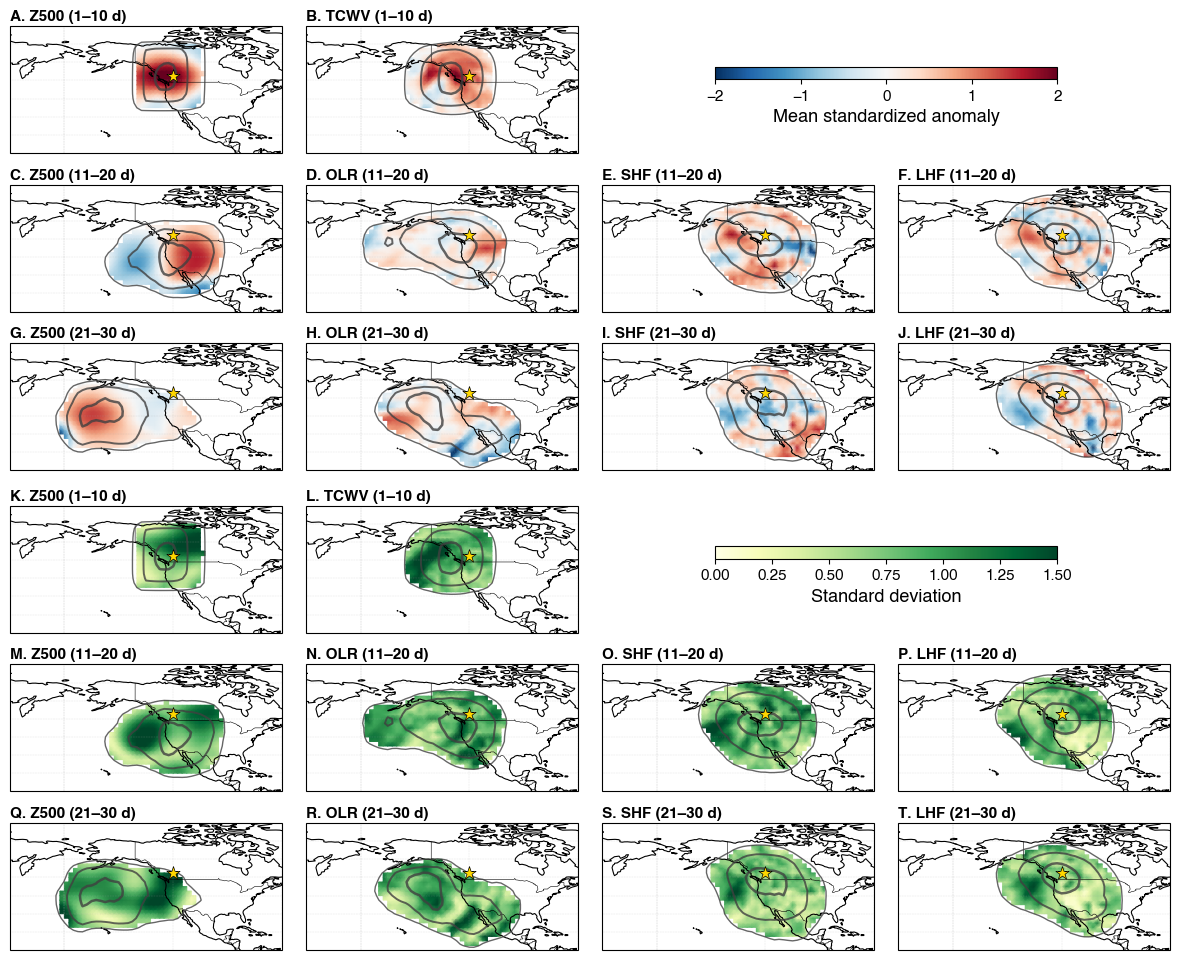

In [31]:
fig5_stack, axes5_stack = plot_pnw_physical_patterns_stacked_mean_std(
    full_data_run=full_data_run,
    pooled_members=pooled_members,
    date_end=date_end,
    event_lon=event_lon,
    event_lat=event_lat,
    extent=(120, -30, 10, 80),
    central_longitude=180,

    mean_cmap="RdBu_r",
    mean_vmin=-2,
    mean_vmax=2,

    std_cmap="YlGn",
    std_vmin=0.0,
    std_vmax=1.5,

    contour_color_mode="by_window",
    # contour_color_by_window={
    #     (0, 10): "#c98245",
    #     (10, 20): "#5a284d",
    #     (20, 30): "#5f93d1",
    # },
    contour_color_by_window={
        (0, 10): "0.25",
        (10, 20): "0.25",
        (20, 30): "0.25",
    },
    contour_linewidths=[1, 1.4, 1.8],
    contour_percentiles=[90, 95, 99],
    normalize_density_rows=False,
)

plt.show()

# fig5_stack.savefig("fig_pnw21b.pdf", bbox_inches="tight")

In [32]:
def plot_pnw_physical_patterns_stacked_mean_std(
    full_data_run,
    pooled_members,
    *,
    date_end,
    event_lon,
    event_lat,
    extent=(120, -50, 10, 80),
    central_longitude=180,
    timeres_days=1.0,
    mean_cmap="RdBu_r",
    mean_vmin=-1.5,
    mean_vmax=1.5,
    std_cmap="YlGnBu",
    std_vmin=0.0,
    std_vmax=1.5,
    contour_color_mode="by_window",
    contour_color="k",
    contour_color_by_window=None,
    contour_linewidths=(0.8, 1.1, 1.5),
    contour_percentiles=(90, 95, 99),
    normalize_density_rows=True,
    _only_block=None,  # None = both; "mean" = top only; "std" = bottom only
):
    lat_name, lon_name = _infer_lat_lon_names(full_data_run)

    if contour_color_by_window is None:
        contour_color_by_window = {
            (0, 10): "#c98245",
            (10, 20): "#5a284d",
            (20, 30): "#5f93d1",
        }

    def composite_field_for_window(var_name, a, b, mode="mean"):
        date_end_ts = pd.Timestamp(date_end)
        fields = []
        for step_idx in range(int(a), int(b)):
            target_time = date_end_ts - pd.Timedelta(days=float(step_idx) * float(timeres_days))
            da = full_data_run.sel(var=var_name).sel(time=target_time, method="nearest")
            fields.append(da)
        da_all = xr.concat(fields, dim="window_step")
        if mode == "mean":
            return da_all.mean("window_step")
        elif mode == "std":
            return da_all.std("window_step")
        elif mode == "rms":
            return np.sqrt((da_all ** 2).mean("window_step"))
        else:
            raise ValueError("mode must be 'mean', 'std', or 'rms'")

    def compute_window_density_dict(windows):
        density_dict = {}
        for (a, b) in windows:
            counts, var_names, lats, lons = density_by_variable_for_time_window_boxes_variable_boxsize(
                pooled_members,
                full_data_run=full_data_run,
                t_start=a,
                t_end=b,
            )
            if normalize_density_rows:
                total = counts.sum()
                if total > 0:
                    counts = counts / total
            density_dict[(a, b)] = {
                "counts": counts,
                "var_names": var_names,
                "lats": lats,
                "lons": lons,
            }
        return density_dict

    def get_contour_color_for_window(a, b):
        if contour_color_mode == "single":
            return contour_color
        elif contour_color_mode == "by_window":
            return contour_color_by_window.get((a, b), "0.2")
        else:
            raise ValueError("contour_color_mode must be 'single' or 'by_window'")

    def draw_block(fig, gs_block, field_mode, cmap, vmin, vmax, start_letter_idx):
        row1 = [
            ("Z500", (0, 10)),
            ("TCWV", (0, 10)),
        ]
        row2 = [
            ("Z500", (10, 20)),
            ("MTNLWRF", (10, 20)),
            ("MSSHF", (10, 20)),
            ("MSLHF", (10, 20)),
        ]
        row3 = [
            ("Z500", (20, 30)),
            ("MTNLWRF", (20, 30)),
            ("MSSHF", (20, 30)),
            ("MSLHF", (20, 30)),
        ]

        panel_rows = [row1, row2, row3]

        proj = ccrs.PlateCarree(central_longitude=central_longitude)
        axes = []
        mappable_for_cbar = None
        letter_idx = start_letter_idx

        for irow, row_spec in enumerate(panel_rows):
            for icol in range(4):
                if irow == 0 and icol >= 2:
                    continue

                var_name, (a, b) = row_spec[icol]
                ax = fig.add_subplot(gs_block[irow, icol], projection=proj)
                axes.append(ax)

                _style_geo_ax(ax, extent, central_longitude=central_longitude, add_grid=True)

                da_comp = composite_field_for_window(var_name, a, b, mode=field_mode)

                lons = np.asarray(da_comp[lon_name].values, dtype=float)
                lats = np.asarray(da_comp[lat_name].values, dtype=float)
                vals = np.asarray(da_comp.values, dtype=float)

                lon_plot, vals_plot = _subset_lon_no_wrap(lons, vals, extent)

                # --------------------------------------------------
                # Density contours + masking
                # --------------------------------------------------
                dens_info = density_dict[(a, b)]
                counts = dens_info["counts"]
                var_names = dens_info["var_names"]

                k = var_names.index(var_name)
                dens2d = counts[k]

                lons_d = np.asarray(dens_info["lons"], dtype=float)
                lats_d = np.asarray(dens_info["lats"], dtype=float)

                lon_plot_d, dens_plot = _subset_lon_no_wrap(lons_d, dens2d, extent)

                pos_vals = dens_plot[np.isfinite(dens_plot)]
                pos_vals = pos_vals[pos_vals > 0]

                # compute mask from outer (lowest) density contour
                if pos_vals.size > 0:
                    levels = np.percentile(pos_vals, contour_percentiles)
                    levels = np.unique(levels)
                    outer_level = levels[0]  # 90th percentile = outermost contour

                    from scipy.interpolate import RegularGridInterpolator
                    interp = RegularGridInterpolator(
                        (lats_d, lon_plot_d),
                        dens_plot,
                        method="linear",
                        bounds_error=False,
                        fill_value=0.0,
                    )
                    LON2d, LAT2d = np.meshgrid(lon_plot, lats)
                    dens_on_field_grid = interp((LAT2d, LON2d))
                    vals_plot_masked = vals_plot.copy()
                    vals_plot_masked[dens_on_field_grid < outer_level] = np.nan
                else:
                    levels = None
                    vals_plot_masked = vals_plot.copy()

                mesh = ax.pcolormesh(
                    lon_plot,
                    lats,
                    vals_plot_masked,
                    transform=ccrs.PlateCarree(),
                    shading="gouraud",
                    cmap=cmap,
                    vmin=vmin,
                    vmax=vmax,
                    zorder=1,
                    rasterized=True,
                )
                mappable_for_cbar = mesh

                # --------------------------------------------------
                # Draw density contours
                # --------------------------------------------------
                if pos_vals.size > 0 and levels is not None and len(levels) > 0:
                    this_color = get_contour_color_for_window(a, b)
                    contour_colors_use = [this_color] * len(levels)

                    if len(contour_linewidths) < len(levels):
                        contour_lw_use = (
                            list(contour_linewidths)
                            + [contour_linewidths[-1]] * (len(levels) - len(contour_linewidths))
                        )
                    else:
                        contour_lw_use = list(contour_linewidths)[:len(levels)]

                    ax.contour(
                        lon_plot_d,
                        lats_d,
                        dens_plot,
                        levels=levels,
                        colors=contour_colors_use,
                        linewidths=contour_lw_use,
                        transform=ccrs.PlateCarree(),
                        zorder=3,
                        alpha=0.8,
                    )

                ax.scatter(
                    ((event_lon + 180) % 360) - 180,
                    event_lat,
                    marker="*",
                    s=100,
                    color="gold",
                    edgecolor="k",
                    linewidth=0.5,
                    transform=ccrs.PlateCarree(),
                    zorder=4,
                )

                label = VAR_LABELS_PNW.get(var_name, var_name)
                win_label = (
                    "1–10 d" if (a, b) == (0, 10)
                    else "11–20 d" if (a, b) == (10, 20)
                    else "21–30 d"
                )

                ax.set_title(
                    f"{chr(65 + letter_idx)}. {label} ({win_label})",
                    loc="left",
                    fontsize=11,
                    fontweight="bold",
                    pad=4,
                )
                letter_idx += 1

        # top-right colorbar slot for this block
        tmp_ax = fig.add_subplot(gs_block[0, 2:4])
        pos = tmp_ax.get_position()
        tmp_ax.remove()

        cax = fig.add_axes([
            pos.x0 + 0.20 * pos.width,
            pos.y0 + 0.58 * pos.height,
            0.60 * pos.width,
            0.10 * pos.height,
        ])

        cb = fig.colorbar(mappable_for_cbar, cax=cax, orientation="horizontal")
        cb_label = "Mean standardized anomaly" if field_mode == "mean" else "Standard deviation"
        cb.set_label(cb_label, fontsize=13)
        cb.ax.tick_params(labelsize=11)
        cb.outline.set_linewidth(0.8)

        return axes, letter_idx

    # --------------------------------------------------
    # Shared density dict
    # --------------------------------------------------
    all_windows = [(0, 10), (10, 20), (20, 30)]
    density_dict = compute_window_density_dict(all_windows)

    # --------------------------------------------------
    # Figure — single or stacked
    # --------------------------------------------------
    if _only_block is None:
        fig = plt.figure(figsize=(15, 12))
        outer = gridspec.GridSpec(2, 1, figure=fig, hspace=0.08)
        gs_top = gridspec.GridSpecFromSubplotSpec(
            3, 4, subplot_spec=outer[0], hspace=0.25, wspace=0.08
        )
        gs_bot = gridspec.GridSpecFromSubplotSpec(
            3, 4, subplot_spec=outer[1], hspace=0.25, wspace=0.08
        )
        axes_top, _ = draw_block(fig, gs_top, "mean", mean_cmap, mean_vmin, mean_vmax, 0)
        axes_bot, _ = draw_block(fig, gs_bot, "std",  std_cmap,  std_vmin,  std_vmax,  10)
        return fig, axes_top + axes_bot

    else:
        fig = plt.figure(figsize=(15, 6.5))
        gs_single = gridspec.GridSpec(
            3, 4, figure=fig,
            hspace=0.25, wspace=0.08,
            left=0.04, right=0.96, top=0.95, bottom=0.06,
        )
        if _only_block == "mean":
            axes, _ = draw_block(fig, gs_single, "mean", mean_cmap, mean_vmin, mean_vmax, 0)
        elif _only_block == "std":
            axes, _ = draw_block(fig, gs_single, "std", std_cmap, std_vmin, std_vmax, 0)
        else:
            raise ValueError("_only_block must be None, 'mean', or 'std'")
        return fig, axes

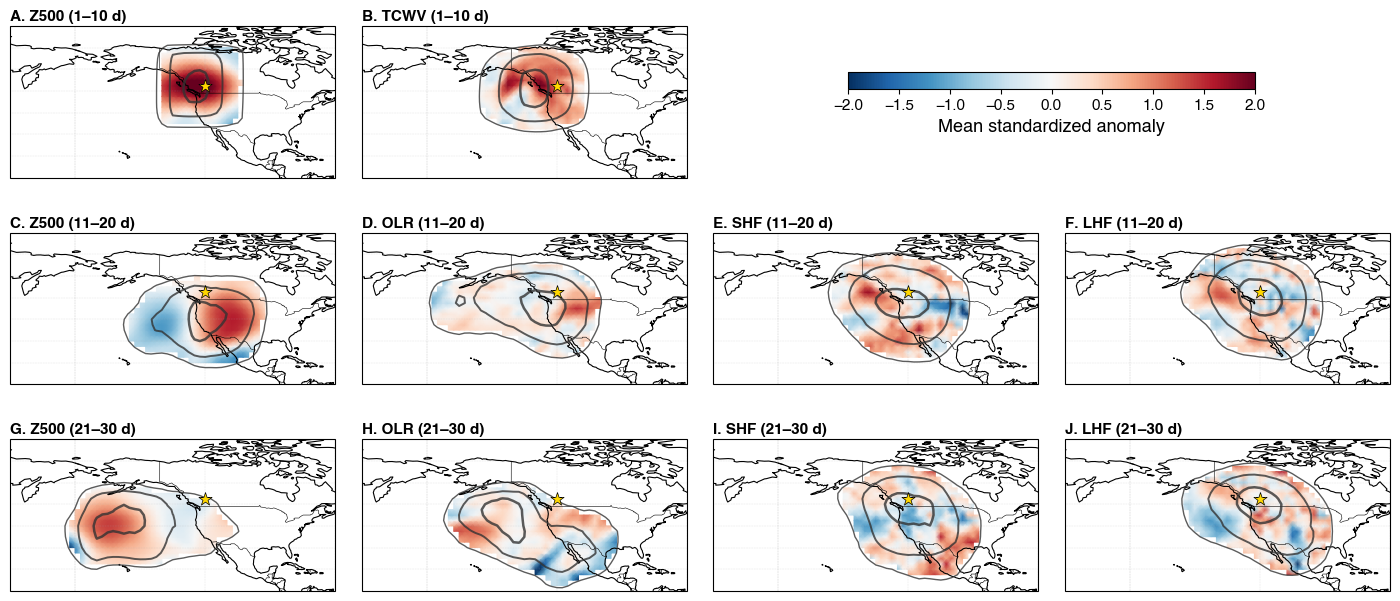

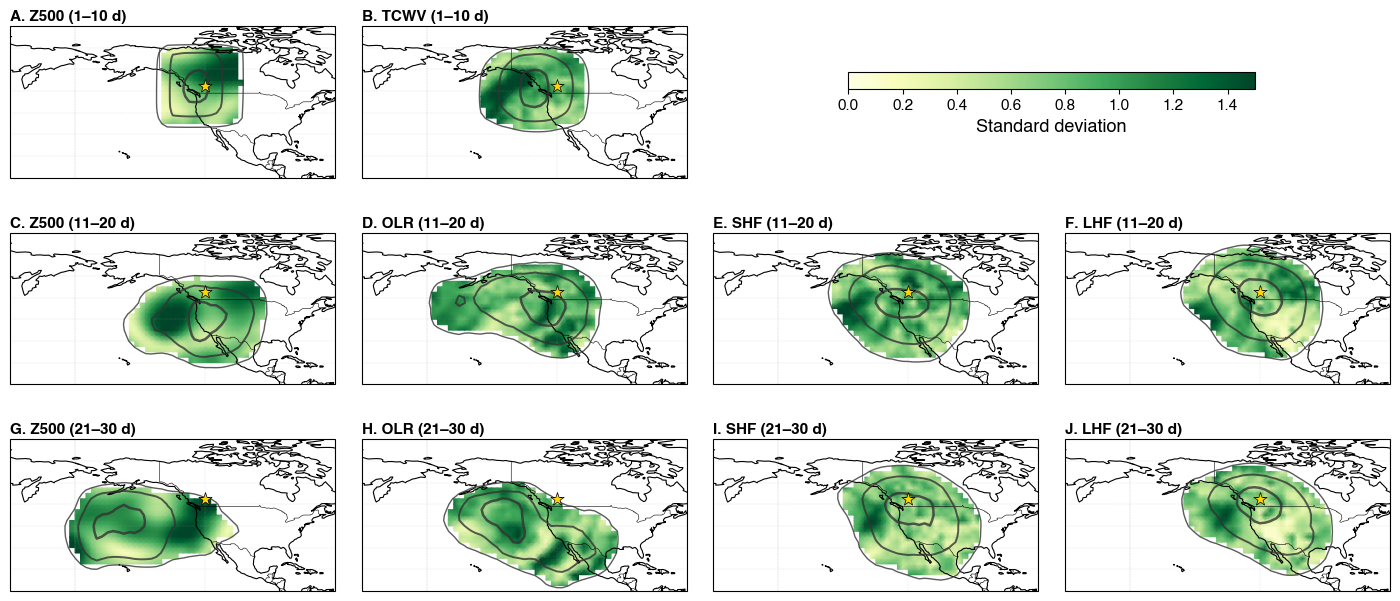

In [35]:
SHARED_KWARGS = dict(
    full_data_run=full_data_run,
    pooled_members=pooled_members,
    date_end=date_end,
    event_lon=event_lon,
    event_lat=event_lat,
    extent=(120, -30, 10, 80),
    central_longitude=180,
    mean_cmap="RdBu_r", mean_vmin=-2, mean_vmax=2,
    std_cmap="YlGn",    std_vmin=0.0, std_vmax=1.5,
    contour_color_mode="by_window",
    contour_color_by_window={"(0, 10)": "0.25", "(10, 20)": "0.25", "(20, 30)": "0.25"},
    contour_linewidths=[1, 1.4, 1.8],
    contour_percentiles=[90, 95, 99],
    normalize_density_rows=False,
)

fig_mean, _ = plot_pnw_physical_patterns_stacked_mean_std(**SHARED_KWARGS, _only_block="mean")
plt.show()
fig_mean.savefig("fig_pnw_21b_v2.pdf", bbox_inches="tight")

fig_std, _ = plot_pnw_physical_patterns_stacked_mean_std(**SHARED_KWARGS, _only_block="std")
plt.show()
fig_std.savefig("sup_pnw21b_std.pdf", bbox_inches="tight")

In [26]:
def plot_compact_density_contours_by_var(
    pooled_members,
    full_data_run,
    *,
    windows=((0, 10), (10, 20), (20, 30)),
    window_labels=("1–10 d", "11–20 d", "21–30 d"),
    window_colors=("#b12ad4", "#6a7fdc", "#63d4de"),
    extent=(90, -40, 10, 80),
    central_longitude=180,
    normalize_rows=True,

    # -------------------------------
    # Contour-level options
    # -------------------------------
    contour_level_mode="global_by_window",
    # options:
    #   "global_by_window"      -> one level per window across all variables
    #   "per_variable_by_window"-> one level per (variable, window)
    #   "manual"                -> use contour_levels directly
    contour_levels=(0.006, 0.0015, 0.0010),
    contour_percentiles=None,
    contour_linewidths=(2.2, 2.2, 2.2),
    contour_linestyles=("solid", "solid", "solid"),

    event_lon=None,
    event_lat=None,
    figsize_per_panel=2.9,
    title="Compact variable-specific densities by window",

    # -------------------------------
    # Background options
    # -------------------------------
    show_background=False,
    background_mode="full_30d",   # "full_30d" or "single_window"
    background_window_index=0,
    background_cmap="Greys",
    background_alpha=0.18,
    background_vmax=None,
    background_percentile=99.5,
    background_add_colorbar=False,
    background_cbar_label="Full 30-day density",
):
    """
    Plot 6 panels (one per variable), overlaying one contour for each lead-time window.

    Contour-level modes
    -------------------
    contour_level_mode = "global_by_window"
        One contour level per time window, computed pooling all variables together.

    contour_level_mode = "per_variable_by_window"
        One contour level for each variable and each time window.

    contour_level_mode = "manual"
        Uses contour_levels directly.

    Notes
    -----
    - For "global_by_window", contour_levels has shape (n_windows,)
    - For "per_variable_by_window", resolved levels internally have shape
      (n_windows, n_vars)
    """

    var_names = [str(v) for v in full_data_run["var"].values]
    n_vars = len(var_names)
    n_windows = len(windows)

    if len(window_labels) != n_windows:
        raise ValueError("window_labels must have same length as windows")
    if len(window_colors) != n_windows:
        raise ValueError("window_colors must have same length as windows")
    if len(contour_linewidths) != n_windows:
        raise ValueError("contour_linewidths must have same length as windows")
    if len(contour_linestyles) != n_windows:
        raise ValueError("contour_linestyles must have same length as windows")

    # --------------------------------------------------
    # Compute densities for each window
    # --------------------------------------------------
    counts_rows = []
    lats = None
    lons = None

    for (a, b) in windows:
        counts, _, lats, lons = density_by_variable_for_time_window_boxes_variable_boxsize(
            pooled_members,
            full_data_run=full_data_run,
            t_start=a,
            t_end=b,
        )
        counts_rows.append(counts.astype(float))

    if normalize_rows:
        counts_rows_norm = []
        for counts in counts_rows:
            total = counts.sum()
            counts_rows_norm.append(counts / total if total > 0 else counts.copy())
        counts_rows = counts_rows_norm

    # --------------------------------------------------
    # Longitude ordering for plotting
    # --------------------------------------------------
    lon_pm = ((lons + 180) % 360) - 180
    order = np.argsort(lon_pm)
    lon_plot = lon_pm[order]

    # --------------------------------------------------
    # Resolve contour levels
    # --------------------------------------------------
    contour_levels_resolved = None  # shape:
                                    #   (n_windows,) for global/manual
                                    #   (n_windows, n_vars) for per-variable mode

    if contour_level_mode == "manual":
        contour_levels = np.asarray(contour_levels, dtype=float)
        if contour_levels.ndim != 1 or len(contour_levels) != n_windows:
            raise ValueError(
                "For contour_level_mode='manual', contour_levels must have shape (n_windows,)"
            )
        contour_levels_resolved = contour_levels

    elif contour_level_mode == "global_by_window":
        if contour_percentiles is None:
            raise ValueError(
                "For contour_level_mode='global_by_window', provide contour_percentiles"
            )
        if len(contour_percentiles) != n_windows:
            raise ValueError("contour_percentiles must have same length as windows")

        resolved_levels = []
        for iwin, counts in enumerate(counts_rows):
            pos = counts[np.isfinite(counts)]
            pos = pos[pos > 0]
            if pos.size == 0:
                resolved_levels.append(np.nan)
            else:
                resolved_levels.append(np.percentile(pos, contour_percentiles[iwin]))
        contour_levels_resolved = np.asarray(resolved_levels, dtype=float)

    elif contour_level_mode == "per_variable_by_window":
        if contour_percentiles is None:
            raise ValueError(
                "For contour_level_mode='per_variable_by_window', provide contour_percentiles"
            )
        if len(contour_percentiles) != n_windows:
            raise ValueError("contour_percentiles must have same length as windows")

        resolved_levels = np.full((n_windows, n_vars), np.nan, dtype=float)

        for iwin, counts in enumerate(counts_rows):
            for icol in range(n_vars):
                H = counts[icol]
                pos = H[np.isfinite(H)]
                pos = pos[pos > 0]
                if pos.size > 0:
                    resolved_levels[iwin, icol] = np.percentile(
                        pos, contour_percentiles[iwin]
                    )

        contour_levels_resolved = resolved_levels

    else:
        raise ValueError(
            "contour_level_mode must be one of: "
            "'manual', 'global_by_window', 'per_variable_by_window'"
        )

    # --------------------------------------------------
    # Build background field
    # --------------------------------------------------
    background_counts = None
    background_vmax_resolved = None

    if show_background:
        if background_mode == "full_30d":
            background_counts = np.sum(counts_rows, axis=0)  # (n_vars, lat, lon)

        elif background_mode == "single_window":
            if not (0 <= background_window_index < len(counts_rows)):
                raise ValueError("background_window_index out of range")
            background_counts = counts_rows[background_window_index].copy()

        else:
            raise ValueError("background_mode must be 'full_30d' or 'single_window'")

        bg_pos = background_counts[np.isfinite(background_counts)]
        bg_pos = bg_pos[bg_pos > 0]

        if background_vmax is None:
            background_vmax_resolved = (
                np.percentile(bg_pos, background_percentile) if bg_pos.size else 1.0
            )
        else:
            background_vmax_resolved = float(background_vmax)

    # --------------------------------------------------
    # Helpful diagnostics
    # --------------------------------------------------
    print("\nChosen contour levels:")

    if contour_level_mode in ("manual", "global_by_window"):
        for label, lev in zip(window_labels, contour_levels_resolved):
            print(f"  {label}: {lev:.6g}")

    elif contour_level_mode == "per_variable_by_window":
        for iwin, label in enumerate(window_labels):
            print(f"  {label}:")
            for icol, vname in enumerate(var_names):
                lev = contour_levels_resolved[iwin, icol]
                if np.isfinite(lev):
                    print(f"    {vname}: {lev:.6g}")
                else:
                    print(f"    {vname}: nan")

    print("\nWindow-wise positive-density summaries:")
    for label, counts in zip(window_labels, counts_rows):
        pos = counts[np.isfinite(counts)]
        pos = pos[pos > 0]
        if pos.size == 0:
            print(f"  {label}: no positive values")
        else:
            print(
                f"  {label}: min={pos.min():.6g}, "
                f"p90={np.percentile(pos, 90):.6g}, "
                f"p95={np.percentile(pos, 95):.6g}, "
                f"p99={np.percentile(pos, 99):.6g}, "
                f"max={pos.max():.6g}"
            )

    if contour_level_mode == "per_variable_by_window":
        print("\nPer-variable/window summaries:")
        for iwin, label in enumerate(window_labels):
            print(f"  {label}:")
            for icol, vname in enumerate(var_names):
                H = counts_rows[iwin][icol]
                pos = H[np.isfinite(H)]
                pos = pos[pos > 0]
                if pos.size == 0:
                    print(f"    {vname}: no positive values")
                else:
                    print(
                        f"    {vname}: "
                        f"p90={np.percentile(pos, 90):.6g}, "
                        f"p95={np.percentile(pos, 95):.6g}, "
                        f"p99={np.percentile(pos, 99):.6g}, "
                        f"max={pos.max():.6g}"
                    )

    if show_background:
        bg_pos = background_counts[np.isfinite(background_counts)]
        bg_pos = bg_pos[bg_pos > 0]
        print(f"\nRequested background_vmax: {background_vmax}")
        print(f"Resolved background_vmax: {background_vmax_resolved}")

        if bg_pos.size > 0:
            print("\nBackground positive-density summary:")
            print(
                f"  mode={background_mode}, "
                f"min={bg_pos.min():.6g}, "
                f"p90={np.percentile(bg_pos, 90):.6g}, "
                f"p95={np.percentile(bg_pos, 95):.6g}, "
                f"p99={np.percentile(bg_pos, 99):.6g}, "
                f"max={bg_pos.max():.6g}, "
                f"common vmax={background_vmax_resolved:.6g}"
            )

    # --------------------------------------------------
    # Figure
    # --------------------------------------------------
    proj = ccrs.PlateCarree(central_longitude=central_longitude)
    geo = ccrs.PlateCarree()

    fig, axes = plt.subplots(
        1,
        n_vars,
        figsize=(max(14, figsize_per_panel * n_vars), 3.3),
        subplot_kw=dict(projection=proj),
        squeeze=False,
    )
    axes = axes[0]

    bg_mesh = None

    for icol, vname in enumerate(var_names):
        ax = axes[icol]
        _style_geo_ax(ax, extent, central_longitude=central_longitude, add_grid=True)

        # --------------------------------------------------
        # Optional background shading
        # --------------------------------------------------
        if show_background:
            Hbg = background_counts[icol][:, order]
            bg_mesh = ax.pcolormesh(
                lon_plot,
                lats,
                Hbg,
                transform=geo,
                shading="auto",
                cmap=background_cmap,
                vmin=0,
                vmax=background_vmax_resolved,
                alpha=background_alpha,
                zorder=1,
                rasterized=True,
            )

        # --------------------------------------------------
        # Overlaid contours, one per window
        # --------------------------------------------------
        for iwin, (label, color, lw, ls) in enumerate(
            zip(window_labels, window_colors, contour_linewidths, contour_linestyles)
        ):
            H = counts_rows[iwin][icol][:, order]

            if contour_level_mode in ("manual", "global_by_window"):
                lev = contour_levels_resolved[iwin]
            else:
                lev = contour_levels_resolved[iwin, icol]

            if not np.isfinite(lev):
                continue

            pos = H[np.isfinite(H)]
            pos = pos[pos > 0]
            if pos.size == 0:
                continue

            if np.nanmax(H) < lev:
                continue

            ax.contour(
                lon_plot,
                lats,
                H,
                levels=[lev],
                colors=[color],
                linewidths=[lw],
                linestyles=[ls],
                transform=geo,
                zorder=3 + iwin,
            )

        if event_lon is not None and event_lat is not None:
            ax.scatter(
                ((event_lon + 180) % 360) - 180,
                event_lat,
                marker="*",
                s=55,
                color="gold",
                edgecolor="k",
                linewidth=0.5,
                transform=geo,
                zorder=10,
            )

        ax.set_title(
            VAR_LABELS_PNW.get(vname, vname),
            fontsize=12,
            fontweight="bold",
            pad=5,
        )

    # --------------------------------------------------
    # Legend
    # --------------------------------------------------
    legend_handles = [
        Line2D([0], [0], color=c, lw=2.6, linestyle=ls, label=lab)
        for c, ls, lab in zip(window_colors, contour_linestyles, window_labels)
    ]
    if event_lon is not None and event_lat is not None:
        legend_handles.append(
            Line2D(
                [0], [0],
                marker="*",
                color="gold",
                markeredgecolor="k",
                linestyle="None",
                markersize=10,
                label="Target point",
            )
        )

    fig.legend(
        handles=legend_handles,
        loc="lower center",
        bbox_to_anchor=(0.5, 0.15),
        ncol=len(legend_handles),
        frameon=True,
        fontsize=10,
        handlelength=2.5,
        columnspacing=1.2,
    )

    # --------------------------------------------------
    # Optional background colorbar
    # --------------------------------------------------
    if show_background and background_add_colorbar and (bg_mesh is not None):
        cax = fig.add_axes([0.30, 0.085, 0.40, 0.03])
        cb = fig.colorbar(bg_mesh, cax=cax, orientation="horizontal")
        cb.set_label(background_cbar_label, fontsize=10)
        cb.ax.tick_params(labelsize=9)

    if title is not None:
        fig.suptitle(title, fontsize=14, fontweight="bold", y=0.98)

    fig.subplots_adjust(
        left=0.04,
        right=0.995,
        top=0.86,
        bottom=0.16 if not (show_background and background_add_colorbar) else 0.20,
        wspace=0.05,
    )

    return fig, axes


Chosen contour levels:
  1–10 d:
    Z500: 16650.8
    Z10: 1603.7
    MTNLWRF: 3933.6
    TCWV: 6689.5
    MSLHF: 4178.15
    MSSHF: 4469
  11–20 d:
    Z500: 1539
    Z10: 864
    MTNLWRF: 2530.1
    TCWV: 2124.95
    MSLHF: 2604.95
    MSSHF: 2730.2
  21–30 d:
    Z500: 1108.6
    Z10: 548.4
    MTNLWRF: 1740.15
    TCWV: 1196
    MSLHF: 1668.2
    MSSHF: 1559.25

Window-wise positive-density summaries:
  1–10 d: min=1, p90=2464, p95=4837, p99=12548, max=19729
  11–20 d: min=1, p90=1385, p95=2158, p99=3447, max=4528
  21–30 d: min=1, p90=929, p95=1387.35, p99=2147.07, max=2793

Per-variable/window summaries:
  1–10 d:
    Z500: p90=6687.5, p95=16650.8, p99=19485, max=19729
    Z10: p90=1063.4, p95=1603.7, p99=2091.51, max=2164
    MTNLWRF: p90=2467, p95=3933.6, p99=5566.78, max=6117
    TCWV: p90=3526.5, p95=6689.5, p99=10170.3, max=10948
    MSLHF: p90=2476.2, p95=4178.15, p99=5965.03, max=6458
    MSSHF: p90=2691, p95=4469, p99=6411.9, max=6966
  11–20 d:
    Z500: p90=979.4, p95

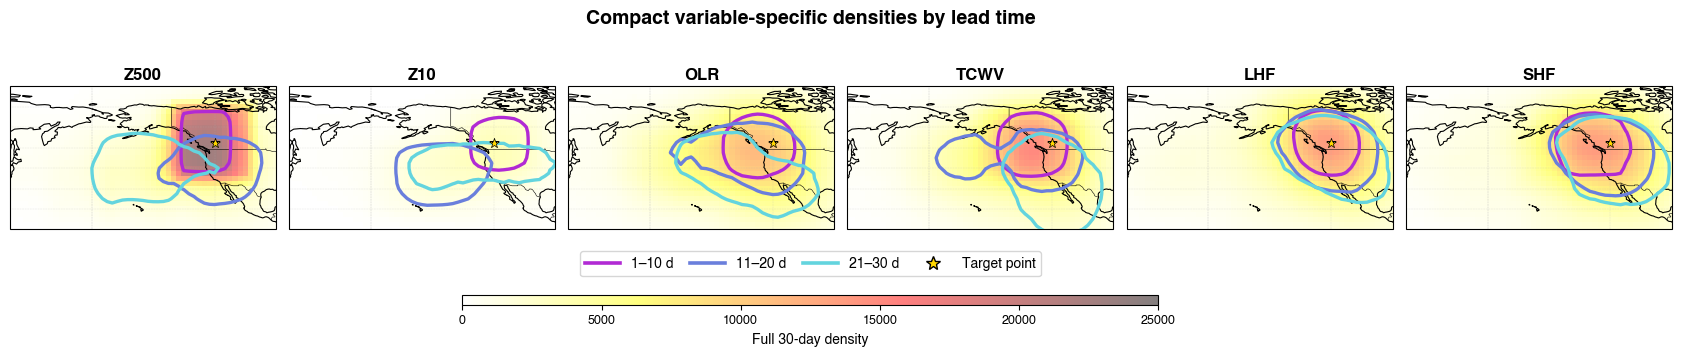

In [27]:
fig6c, axes6c = plot_compact_density_contours_by_var(
    pooled_members,
    full_data_run,
    windows=((0, 10), (10, 20), (20, 30)),
    window_labels=("1–10 d", "11–20 d", "21–30 d"),
    window_colors=("#b12ad4", "#6a7fdc", "#63d4de"),
    extent=(90, -40, 10, 80),
    central_longitude=180,
    normalize_rows=False,

    contour_level_mode="per_variable_by_window",
    contour_percentiles=(95, 95, 95),

    contour_linewidths=(2.4, 2.4, 2.4),
    contour_linestyles=("solid", "solid", "solid"),
    event_lon=event_lon,
    event_lat=event_lat,
    figsize_per_panel=2.9,
    title="Compact variable-specific densities by lead time",

    show_background=True,
    background_mode="full_30d",
    background_cmap="hot_r",
    background_alpha=0.5,
    background_vmax=25000,
    background_add_colorbar=True,
    background_cbar_label="Full 30-day density",
)

plt.show()

In [28]:
from matplotlib.collections import LineCollection
# =========================================================
# Figure 4A replacement:
# representative trajectories for one selected ensemble,
# with optional sparse TraCE-ST boxes and continuous lag colors
# =========================================================

import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.lines import Line2D
from matplotlib.patches import Rectangle
import cartopy.crs as ccrs
import cartopy.feature as cfeature


def plot_selected_ensemble_trajectories_panel(
    ensemble_results,
    full_data_run,
    *,
    box_size,
    timeres_hours=24.0,
    extent=(90, -40, 10, 80),
    central_longitude=180,
    title="A. Representative trajectories",
    n_members=None,
    seed=42,

    # continuous lead-time color
    cmap_name="cool_r",
    lag_vmin=0,
    lag_vmax=None,

    # trajectory aesthetics
    line_color="0.35",
    line_alpha=0.18,
    line_width=0.8,
    point_alpha=0.65,
    point_size=18,

    # box aesthetics
    show_boxes=True,
    box_alpha=0.0,
    box_edge_alpha=0.08,
    box_linewidth=0.45,
    box_every=1,
    n_members_boxes=None,
    seed_boxes=None,
    box_start_step=0,
    box_max_step=None,
    box_fill=False,
    box_zorder=1.5,

    # event marker
    event_lon=None,
    event_lat=None,
    event_marker="*",
    event_color="gold",
    event_size=120,

    # legend/colorbar
    show_variable_legend=True,
    variable_legend_loc="upper center",
    variable_legend_bbox=(0.5, -0.10),
    variable_legend_ncol=4,
    show_colorbar=True,
    colorbar_label="Days back from target",
    colorbar_pad=0.02,
    colorbar_shrink=0.82,

    figsize=(5.2, 3.1),
):
    successful = [r for r in ensemble_results if r.get("success", True)]
    if len(successful) == 0:
        raise ValueError("No successful ensemble members found.")

    # --------------------------------------------------
    # Select plotted members
    # --------------------------------------------------
    if n_members is not None:
        rng = np.random.default_rng(seed)
        n_members = min(int(n_members), len(successful))
        idx = rng.choice(len(successful), size=n_members, replace=False)
        successful = [successful[i] for i in idx]

    n_plotted = len(successful)

    # --------------------------------------------------
    # Select which plotted members receive boxes
    # --------------------------------------------------
    if n_members_boxes is None:
        box_member_indices = set(range(n_plotted))
    else:
        rng_boxes = np.random.default_rng(seed if seed_boxes is None else seed_boxes)
        n_members_boxes = min(int(n_members_boxes), n_plotted)
        box_idx = rng_boxes.choice(n_plotted, size=n_members_boxes, replace=False)
        box_member_indices = set(int(i) for i in box_idx)

    box_every = max(1, int(box_every))
    box_start_step = max(0, int(box_start_step))

    var_names = [str(v) for v in full_data_run["var"].values]
    label_map = VAR_LABELS_PNW if "VAR_LABELS_PNW" in globals() else {}

    marker_cycle = ["o", "s", "^", "D", "P", "X", "v", "<", ">", "*"]
    marker_map = {
        v: marker_cycle[i % len(marker_cycle)]
        for i, v in enumerate(var_names)
    }

    # --------------------------------------------------
    # Continuous lag color setup
    # --------------------------------------------------
    max_steps = max(len(np.asarray(r["centers"])) for r in successful)
    max_days = (max_steps - 1) * float(timeres_hours) / 24.0

    if lag_vmax is None:
        lag_vmax = max_days

    cmap = plt.get_cmap(cmap_name)
    norm = mpl.colors.Normalize(vmin=float(lag_vmin), vmax=float(lag_vmax))

    def color_for_step(step):
        days_back = step * float(timeres_hours) / 24.0
        return cmap(norm(days_back))

    proj = ccrs.PlateCarree(central_longitude=central_longitude)
    geo = ccrs.PlateCarree()

    fig = plt.figure(figsize=figsize)
    ax = plt.axes(projection=proj)

    # --------------------------------------------------
    # Map styling
    # --------------------------------------------------
    ax.set_facecolor("white")
    ax.add_feature(cfeature.LAND, facecolor="white", edgecolor="none", zorder=0)
    ax.add_feature(cfeature.OCEAN, facecolor="white", edgecolor="none", zorder=0)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.8, zorder=5)
    ax.add_feature(cfeature.BORDERS, linewidth=0.4, zorder=5)

    gl = ax.gridlines(draw_labels=False, linewidth=0.35, alpha=0.35, linestyle="--")
    gl.top_labels = False
    gl.right_labels = False

    ax.set_extent(
        extent,
        crs=ccrs.PlateCarree(central_longitude=central_longitude),
    )

    half_box = 0.5 * float(box_size)

    # --------------------------------------------------
    # Plot trajectories, optional boxes, and markers
    # --------------------------------------------------
    for imember, member in enumerate(successful):
        centers = np.asarray(member["centers"], dtype=float)
        parents = np.asarray(member["parents"], dtype=int)

        nT = min(len(centers), len(parents))
        if nT == 0:
            continue

        centers = centers[:nT]
        parents = parents[:nT]

        lats = centers[:, 0]
        lons = centers[:, 1] % 360.0
        steps = np.arange(nT)
        days_back = steps * float(timeres_hours) / 24.0

        # # trajectory line
        # ax.plot(
        #     lons,
        #     lats,
        #     "-",
        #     color=line_color,
        #     linewidth=line_width,
        #     alpha=line_alpha,
        #     transform=geo,
        #     zorder=2,
        # )
        
        # -----------------------------------------
        # trajectory line colored continuously by time
        # -----------------------------------------
        if nT > 1:
        
            # build line segments between consecutive points
            points = np.column_stack([lons, lats]).reshape(-1,1,2)
            segments = np.concatenate(
                [points[:-1], points[1:]],
                axis=1
            )
        
            # color each segment by its starting time
            seg_values = days_back[:-1]
        
            lc = LineCollection(
                segments,
                cmap=cmap,
                norm=norm,
                linewidths=line_width,
                alpha=line_alpha,
                zorder=2,
                transform=geo,
            )
        
            lc.set_array(seg_values)
        
            ax.add_collection(lc)

        # sparse boxes for selected members only
        if show_boxes and (imember in box_member_indices):
            if box_max_step is None:
                step_stop = nT
            else:
                step_stop = min(nT, int(box_max_step))

            box_steps = np.arange(box_start_step+1, step_stop, box_every, dtype=int)

            for step in box_steps:
                lat_c = lats[step]
                lon_c = lons[step]
                c = color_for_step(int(step))

                facecolor = (
                    mpl.colors.to_rgba(c, box_alpha)
                    if box_fill
                    else "none"
                )

                rect = Rectangle(
                    (lon_c - half_box, lat_c - half_box),
                    float(box_size),
                    float(box_size),
                    facecolor=facecolor,
                    edgecolor=mpl.colors.to_rgba(c, box_edge_alpha),
                    linewidth=box_linewidth,
                    transform=geo,
                    zorder=box_zorder,
                )
                ax.add_patch(rect)

        # parent-variable markers, colored continuously by days back
        p0 = np.clip(parents - 1, 0, len(var_names) - 1)
        parent_labels = np.array([var_names[i] for i in p0])

        for vname in var_names:
            mask = parent_labels == vname
            if not np.any(mask):
                continue

            idx = np.where(mask)[0]

            ax.scatter(
                lons[idx],
                lats[idx],
                c=days_back[idx],
                cmap=cmap,
                norm=norm,
                marker=marker_map[vname],
                s=point_size,
                alpha=point_alpha,
                edgecolor="none",
                transform=geo,
                zorder=4,
            )

    # --------------------------------------------------
    # Event marker
    # --------------------------------------------------
    if event_lon is not None and event_lat is not None:
        ax.scatter(
            event_lon,
            event_lat,
            marker=event_marker,
            s=event_size,
            color=event_color,
            edgecolor="k",
            linewidth=0.7,
            transform=geo,
            zorder=10,
        )

    ax.set_title(title, loc="left", fontsize=14, fontweight="bold", pad=5)

    # --------------------------------------------------
    # Variable legend
    # --------------------------------------------------
    if show_variable_legend:
        legend_handles = [
            Line2D(
                [0], [0],
                marker=marker_map[v],
                linestyle="None",
                markerfacecolor="k",
                markeredgecolor="k",
                markersize=6,
                label=label_map.get(v, v),
            )
            for v in var_names
        ]

        if event_lon is not None and event_lat is not None:
            legend_handles.append(
                Line2D(
                    [0], [0],
                    marker=event_marker,
                    linestyle="None",
                    markerfacecolor=event_color,
                    markeredgecolor="k",
                    markersize=8,
                    label="Target point",
                )
            )

        ax.legend(
            handles=legend_handles,
            loc=variable_legend_loc,
            bbox_to_anchor=variable_legend_bbox,
            frameon=True,
            fontsize=8,
            ncol=variable_legend_ncol,
            title="Parent variable / markers",
            title_fontsize=8,
            handlelength=1.4,
            columnspacing=0.9,
            handletextpad=0.5,
            borderaxespad=0.0,
        )

    # --------------------------------------------------
    # Continuous colorbar
    # --------------------------------------------------
    if show_colorbar:
        sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
        sm.set_array([])
        cb = plt.colorbar(
            sm,
            ax=ax,
            orientation="vertical",
            pad=colorbar_pad,
            shrink=colorbar_shrink,
        )
        cb.set_label(colorbar_label, fontsize=9)
        cb.ax.tick_params(labelsize=8)

    plt.tight_layout()
    return fig, ax

Loaded run: 159
n_requested: 30
n_success: 30
n_failed: 0


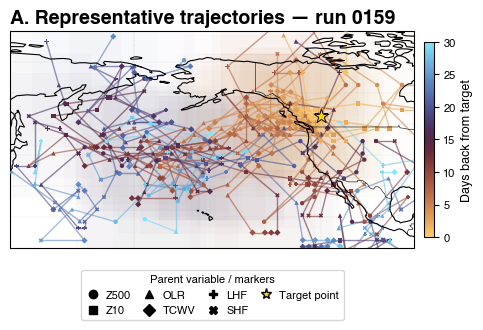

In [29]:
run_id = np.random.choice(df_keep.run_id.values)

params_sel = load_run_params(run_id)
summary_sel = load_run_summary(run_id)
results_sel = load_run_results(run_id)

print("Loaded run:", run_id)
print("n_requested:", summary_sel["n_requested"])
print("n_success:", summary_sel["n_success"])
print("n_failed:", summary_sel["n_failed"])

figA, axA = plot_selected_ensemble_trajectories_panel(
    results_sel,
    full_data_run,
    box_size=params_sel["box_size"],
    timeres_hours=24.0,
    extent=(90, -40, 10, 80),
    central_longitude=180,
    title=f"A. Representative trajectories — run {run_id:04d}",
    n_members=None,
    seed=11,

    # continuous lead-time colors
    cmap_name="managua",
    # cmap_name="rainbow_r",
    lag_vmin=0,
    lag_vmax=30,

    # sparse boxes
    show_boxes=True,
    box_alpha=0.02,
    box_edge_alpha=0.03,
    box_linewidth=0.2,
    box_every=2,
    n_members_boxes=6,
    seed_boxes=4,
    box_fill=True,
    box_start_step=0,
    box_max_step=None,

    # trajectories/points
    line_alpha=0.6,
    line_width=1,
    point_alpha=1.,
    point_size=10,

    event_lon=event_lon,
    event_lat=event_lat,

    # legend/colorbar
    show_variable_legend=True,
    variable_legend_loc="upper center",
    variable_legend_bbox=(0.50, -0.10),
    variable_legend_ncol=4,
    show_colorbar=True,
    colorbar_label="Days back from target",
    colorbar_pad=0.02,
    colorbar_shrink=0.82,

    figsize=(5.2, 3.1),
)

plt.show()


# Optional save
# figA.savefig("fig4A_representative_trajectories_with_sparse_boxes.pdf", bbox_inches="tight")

In [2]:
examples = [117, 80, 36, 107, 205, 259, 264, 184, 127, 208, 94, 189, 227, 259, 239, 195]

Loaded run: 117
n_requested: 30
n_success: 30
n_failed: 0


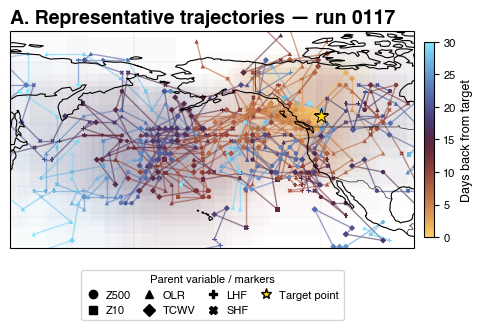

Loaded run: 80
n_requested: 30
n_success: 30
n_failed: 0


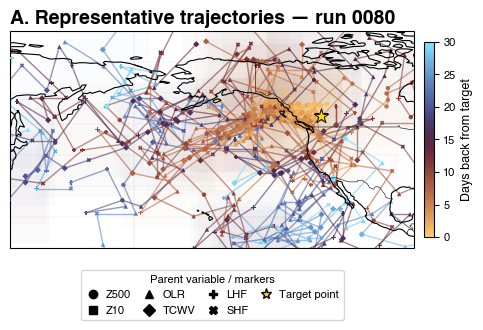

Loaded run: 36
n_requested: 30
n_success: 30
n_failed: 0


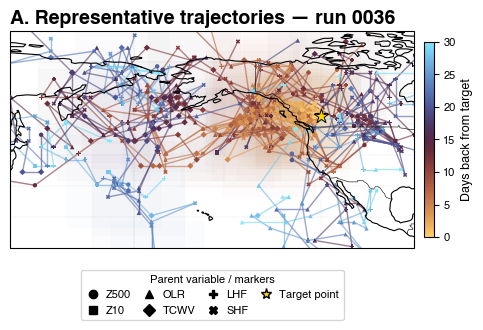

Loaded run: 107
n_requested: 30
n_success: 30
n_failed: 0


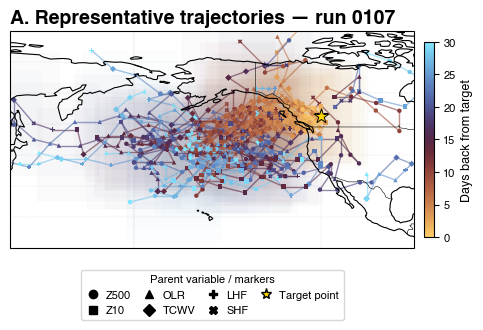

Loaded run: 205
n_requested: 30
n_success: 30
n_failed: 0


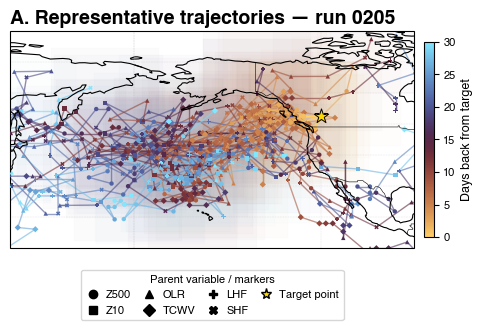

Loaded run: 259
n_requested: 30
n_success: 30
n_failed: 0


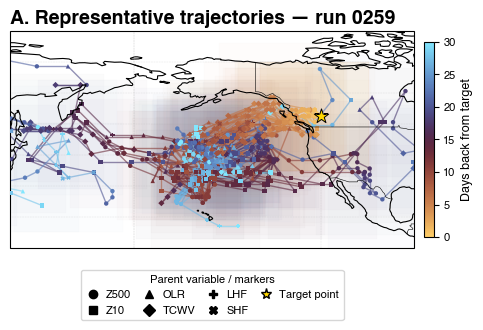

Loaded run: 264
n_requested: 30
n_success: 30
n_failed: 0


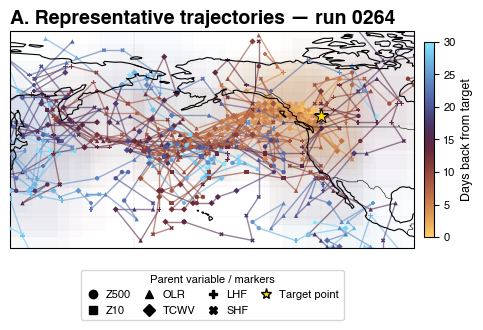

Loaded run: 184
n_requested: 30
n_success: 30
n_failed: 0


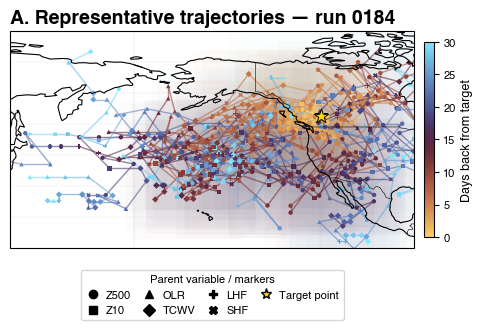

Loaded run: 127
n_requested: 30
n_success: 30
n_failed: 0


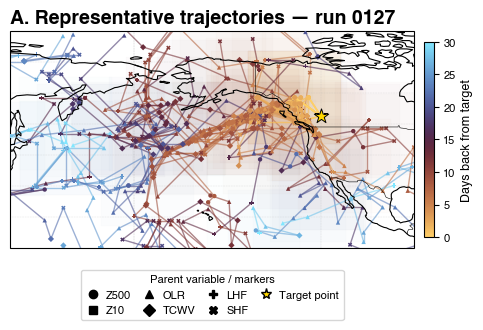

Loaded run: 208
n_requested: 30
n_success: 30
n_failed: 0


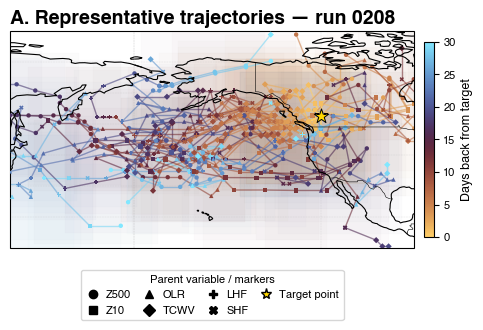

Loaded run: 94
n_requested: 30
n_success: 30
n_failed: 0


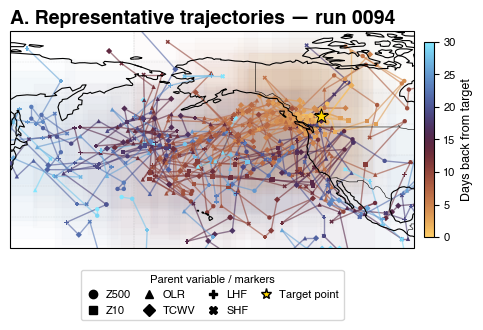

Loaded run: 189
n_requested: 30
n_success: 30
n_failed: 0


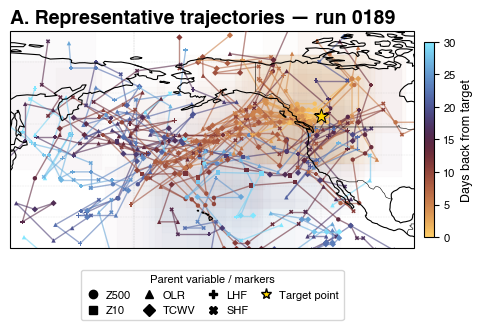

Loaded run: 227
n_requested: 30
n_success: 30
n_failed: 0


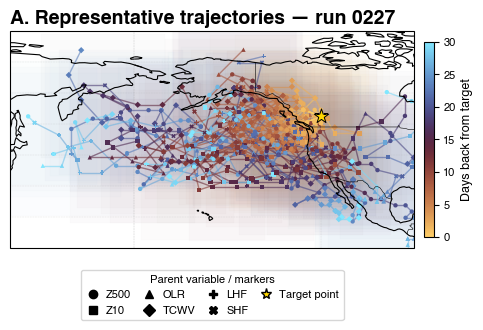

Loaded run: 259
n_requested: 30
n_success: 30
n_failed: 0


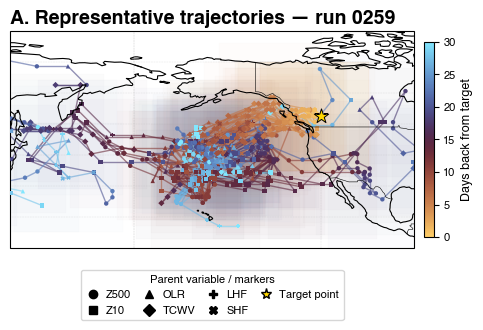

Loaded run: 239
n_requested: 30
n_success: 30
n_failed: 0


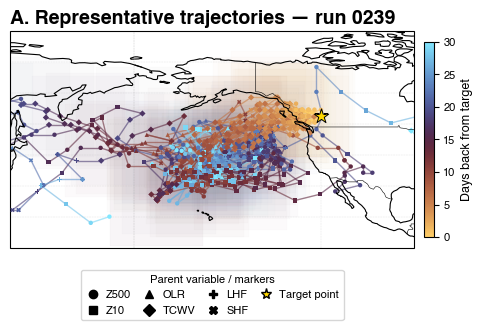

Loaded run: 195
n_requested: 30
n_success: 30
n_failed: 0


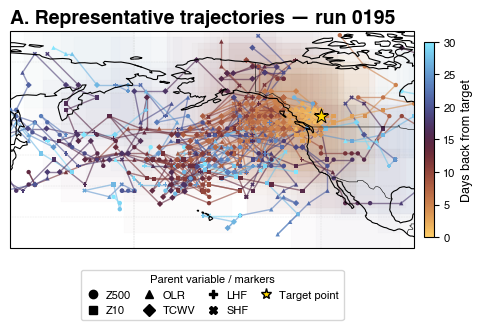

In [31]:
# run_id = 107
run_id = 259
for run_id in examples:
    params_sel = load_run_params(run_id)
    summary_sel = load_run_summary(run_id)
    results_sel = load_run_results(run_id)
    
    print("Loaded run:", run_id)
    print("n_requested:", summary_sel["n_requested"])
    print("n_success:", summary_sel["n_success"])
    print("n_failed:", summary_sel["n_failed"])
    
    figA, axA = plot_selected_ensemble_trajectories_panel(
        results_sel,
        full_data_run,
        box_size=params_sel["box_size"],
        timeres_hours=24.0,
        extent=(90, -40, 10, 80),
        central_longitude=180,
        title=f"A. Representative trajectories — run {run_id:04d}",
        n_members=None,
        seed=11,
    
        # continuous lead-time colors
        cmap_name="managua",
        # cmap_name="rainbow_r",
        lag_vmin=0,
        lag_vmax=30,
    
        # sparse boxes
        show_boxes=True,
        box_alpha=0.02,
        box_edge_alpha=0.03,
        box_linewidth=0.2,
        box_every=2,
        n_members_boxes=6,
        seed_boxes=4,
        box_fill=True,
        box_start_step=0,
        box_max_step=None,
    
        # trajectories/points
        line_alpha=0.6,
        line_width=1,
        point_alpha=1.,
        point_size=10,
    
        event_lon=event_lon,
        event_lat=event_lat,
    
        # legend/colorbar
        show_variable_legend=True,
        variable_legend_loc="upper center",
        variable_legend_bbox=(0.50, -0.10),
        variable_legend_ncol=4,
        show_colorbar=True,
        colorbar_label="Days back from target",
        colorbar_pad=0.02,
        colorbar_shrink=0.82,
    
        figsize=(5.2, 3.1),
    )
    
    plt.show()
    plt.close('all')
    # Optional save
    # figA.savefig("fig4A_representative_trajectories_with_sparse_boxes.pdf", bbox_inches="tight")

In [36]:

def _window_colors_from_cmap(cmap_name="managua", lag_vmin=0, lag_vmax=30, mids=(5, 15, 25)):
    cmap = plt.get_cmap(cmap_name)
    norm = mpl.colors.Normalize(vmin=lag_vmin, vmax=lag_vmax)
    return [cmap(norm(m)) for m in mids]


def _draw_selected_ensemble_panel_v3(
    ax,
    ensemble_results,
    full_data_run,
    *,
    box_size,
    timeres_hours=24.0,
    extent=(90, -40, 10, 80),
    central_longitude=180,
    title="A. Representative trajectories",
    cmap_name="managua",
    lag_vmin=0,
    lag_vmax=30,
    line_alpha=0.45,
    line_width=0.85,
    point_alpha=0.75,
    point_size=8,
    show_boxes=True,
    box_alpha=0.012,
    box_edge_alpha=0.02,
    box_linewidth=0.18,
    box_every=2,
    n_members_boxes=4,
    seed_boxes=4,
    box_fill=True,
    event_lon=None,
    event_lat=None,
):
    successful = [r for r in ensemble_results if r.get("success", True)]
    if len(successful) == 0:
        raise ValueError("No successful ensemble members found.")

    var_names = [str(v) for v in full_data_run["var"].values]
    label_map = VAR_LABELS_PNW if "VAR_LABELS_PNW" in globals() else {}

    # marker_cycle = ["o", "s", "^", "D", "P", "X", "v", "<", ">", "*"]
    marker_cycle = ["o", "o","o","o","o","o","o","o"]
    marker_map = {v: marker_cycle[i % len(marker_cycle)] for i, v in enumerate(var_names)}

    cmap = plt.get_cmap(cmap_name)
    norm = mpl.colors.Normalize(vmin=float(lag_vmin), vmax=float(lag_vmax))

    def color_for_step(step):
        days_back = step * float(timeres_hours) / 24.0
        return cmap(norm(days_back))

    geo = ccrs.PlateCarree()
    _style_geo_ax(ax, extent, central_longitude=central_longitude, add_grid=True)

    n_plotted = len(successful)
    if n_members_boxes is None:
        box_member_indices = set(range(n_plotted))
    else:
        rng_boxes = np.random.default_rng(seed_boxes)
        n_members_boxes = min(int(n_members_boxes), n_plotted)
        box_member_indices = set(rng_boxes.choice(n_plotted, size=n_members_boxes, replace=False))

    half_box = 0.5 * float(box_size)

    for imember, member in enumerate(successful):
        centers = np.asarray(member["centers"], dtype=float)
        parents = np.asarray(member["parents"], dtype=int)

        nT = min(len(centers), len(parents))
        if nT == 0:
            continue

        centers = centers[:nT]
        parents = parents[:nT]

        lats = centers[:, 0]
        lons = centers[:, 1] % 360.0
        steps = np.arange(nT)
        days_back = steps * float(timeres_hours) / 24.0

        if nT > 1:
            points = np.column_stack([lons, lats]).reshape(-1, 1, 2)
            segments = np.concatenate([points[:-1], points[1:]], axis=1)

            lc = LineCollection(
                segments,
                cmap=cmap,
                norm=norm,
                linewidths=line_width,
                alpha=line_alpha,
                zorder=2,
                transform=geo,
            )
            lc.set_array(days_back[:-1])
            ax.add_collection(lc)

        if show_boxes and (imember in box_member_indices):
            box_steps = np.arange(1, nT, max(1, int(box_every)), dtype=int)
            for step in box_steps:
                c = color_for_step(int(step))
                facecolor = mpl.colors.to_rgba(c, box_alpha) if box_fill else "none"

                rect = Rectangle(
                    (lons[step] - half_box, lats[step] - half_box),
                    float(box_size),
                    float(box_size),
                    facecolor=facecolor,
                    edgecolor=mpl.colors.to_rgba(c, box_edge_alpha),
                    linewidth=box_linewidth,
                    transform=geo,
                    zorder=1.5,
                )
                ax.add_patch(rect)

        p0 = np.clip(parents - 1, 0, len(var_names) - 1)
        parent_labels = np.array([var_names[i] for i in p0])

        for vname in var_names:
            mask = parent_labels == vname
            if not np.any(mask):
                continue

            idx = np.where(mask)[0]
            ax.scatter(
                lons[idx],
                lats[idx],
                c=days_back[idx],
                cmap=cmap,
                norm=norm,
                marker=marker_map[vname],
                s=point_size,
                alpha=point_alpha,
                edgecolor="none",
                transform=geo,
                zorder=4,
            )

    if event_lon is not None and event_lat is not None:
        ax.scatter(
            event_lon,
            event_lat,
            marker="*",
            s=100,
            color="gold",
            edgecolor="k",
            linewidth=0.6,
            transform=geo,
            zorder=10,
        )

    ax.set_title(title, loc="left", fontsize=13, fontweight="bold", pad=3)

    handles = [
        Line2D(
            [0], [0],
            marker="*",
            linestyle="None",
            markerfacecolor="gold",
            markeredgecolor="k",
            markersize=7,
            label="Target point",
        )
    ]

    return norm, cmap


def _draw_variable_relevance_panel_v3(
    ax,
    pooled_members,
    full_data_run,
    *,
    windows=((0, 10), (10, 20), (20, 30)),
    window_labels=("Days 1–10", "Days 11–20", "Days 21–30"),
    colors=None,
    title="B. Variable relevance over time",
):
    imp_by_run, var_names = compute_variable_importance_by_run(
        pooled_members,
        full_data_run=full_data_run,
        windows=windows,
        window_labels=window_labels,
    )

    if colors is None:
        colors = ["#b12ad4", "#6a7fdc", "#63d4de"]

    x = np.arange(len(var_names), dtype=float)
    offsets = np.array([-0.26, 0.0, 0.26])
    width = 0.22
    legend_handles = []

    for i, label in enumerate(window_labels):
        arr = np.asarray(imp_by_run[label], dtype=float)
        data_i = []
        pos_i = []

        for j in range(len(var_names)):
            vals = arr[:, j]
            vals = vals[np.isfinite(vals)]
            data_i.append(vals)
            pos_i.append(x[j] + offsets[i])

        bp = ax.boxplot(
            data_i,
            positions=pos_i,
            widths=width,
            patch_artist=True,
            showfliers=True,
            medianprops=dict(color="0.15", linewidth=1.3),
            whiskerprops=dict(color="0.2", linewidth=0.9),
            capprops=dict(color="0.2", linewidth=0.9),
            boxprops=dict(linewidth=0.9, color="0.2"),
        )

        for patch in bp["boxes"]:
            patch.set_facecolor(colors[i])
            patch.set_edgecolor(colors[i])
            patch.set_alpha(0.45)

        legend_handles.append(Line2D([0], [0], color=colors[i], lw=6, alpha=0.65, label=label))

    ax.set_xticks(x)
    ax.set_xticklabels([VAR_LABELS_PNW.get(v, v) for v in var_names], rotation=22, ha="right")
    ax.set_ylabel("Normalized integrated density", fontsize=10)
    ax.grid(True, axis="y", alpha=0.25)
    ax.legend(handles=legend_handles, frameon=True, fontsize=8, loc="upper right")
    ax.set_ylim(bottom=0)
    ax.set_title(title, loc="left", fontsize=13, fontweight="bold", pad=3)


def _precompute_density_panels_v3(
    pooled_members,
    full_data_run,
    *,
    windows=((0, 10), (10, 20), (20, 30)),
    normalize_rows=False,
):
    counts_rows = []
    lats = None
    lons = None
    var_names = None

    for (a, b) in windows:
        counts, var_names, lats, lons = density_by_variable_for_time_window_boxes_variable_boxsize(
            pooled_members,
            full_data_run=full_data_run,
            t_start=a,
            t_end=b,
        )
        counts_rows.append(counts.astype(float))

    if normalize_rows:
        counts_rows = [c / c.sum() if c.sum() > 0 else c.copy() for c in counts_rows]

    background_counts = np.sum(counts_rows, axis=0)

    contour_levels = np.full((len(windows), len(var_names)), np.nan)
    for iwin, counts in enumerate(counts_rows):
        for ivar in range(len(var_names)):
            H = counts[ivar]
            pos = H[np.isfinite(H)]
            pos = pos[pos > 0]
            if pos.size > 0:
                contour_levels[iwin, ivar] = np.percentile(pos, 95)

    lon_pm = ((np.asarray(lons) + 180) % 360) - 180
    order = np.argsort(lon_pm)

    return {
        "counts_rows": counts_rows,
        "background_counts": background_counts,
        "contour_levels": contour_levels,
        "var_names": var_names,
        "lats": np.asarray(lats),
        "lons": np.asarray(lons),
        "lon_plot": lon_pm[order],
        "order": order,
    }


def _draw_density_variable_panel_v3(
    ax,
    density_info,
    *,
    ivar,
    panel_label,
    extent=(90, -40, 10, 80),
    central_longitude=180,
    background_cmap="hot_r",
    background_vmax=25000,
    background_alpha=0.40,
    contour_colors=None,
    contour_linewidths=(1.7, 1.7, 1.7),
    event_lon=None,
    event_lat=None,
):
    geo = ccrs.PlateCarree()
    _style_geo_ax(ax, extent, central_longitude=central_longitude, add_grid=True)

    var_names = density_info["var_names"]
    lats = density_info["lats"]
    lon_plot = density_info["lon_plot"]
    order = density_info["order"]

    if contour_colors is None:
        contour_colors = ["#b12ad4", "#6a7fdc", "#63d4de"]

    Hbg = density_info["background_counts"][ivar][:, order]
    mesh = ax.pcolormesh(
        lon_plot,
        lats,
        Hbg,
        transform=geo,
        shading="auto",
        cmap=background_cmap,
        vmin=0,
        vmax=background_vmax,
        alpha=background_alpha,
        zorder=1,
        rasterized=True,
    )

    for iwin, color in enumerate(contour_colors):
        H = density_info["counts_rows"][iwin][ivar][:, order]
        lev = density_info["contour_levels"][iwin, ivar]

        if not np.isfinite(lev) or np.nanmax(H) < lev:
            continue

        ax.contour(
            lon_plot,
            lats,
            H,
            levels=[lev],
            colors=[color],
            linewidths=[contour_linewidths[iwin]],
            transform=geo,
            zorder=4 + iwin,
        )

    if event_lon is not None and event_lat is not None:
        ax.scatter(
            ((event_lon + 180) % 360) - 180,
            event_lat,
            marker="*",
            s=100,
            color="gold",
            edgecolor="k",
            linewidth=0.5,
            transform=geo,
            zorder=10,
        )

    vlabel = VAR_LABELS_PNW.get(var_names[ivar], var_names[ivar])
    ax.set_title(f"{panel_label}. {vlabel}", loc="left", fontsize=12, fontweight="bold", pad=3)

    return mesh


def plot_trace_st_new_fig4_compact_right_cbar(
    *,
    results_sel,
    params_sel,
    pooled_members,
    full_data_run,
    run_id,
    windows=((0, 10), (10, 20), (20, 30)),
    window_labels=("1–10 d", "11–20 d", "21–30 d"),
    extent=(90, -40, 10, 80),
    central_longitude=180,
    event_lon=None,
    event_lat=None,
    cmap_name="managua",
    background_cmap="hot_r",
    background_vmax=25000,
    background_alpha=0.40,
    figsize=(16, 7.6),
):
    proj = ccrs.PlateCarree(central_longitude=central_longitude)
    fig = plt.figure(figsize=figsize)

    outer = gridspec.GridSpec(
        3,
        7,
        figure=fig,
        height_ratios=[1.05, 1.0, 1.0],
        width_ratios=[1, 1, 1, 1, 1, 1, 0.075],
        wspace=0.16,   # was 0.35
        hspace=0.3,   # was 0.34
        left=0.045,
        right=0.965,
        top=0.935,
        bottom=0.070,
    )

    axA = fig.add_subplot(outer[0, 0:3], projection=proj)
    axB = fig.add_subplot(outer[0, 3:6])

    density_axes = [
        fig.add_subplot(outer[1, 0:2], projection=proj),
        fig.add_subplot(outer[1, 2:4], projection=proj),
        fig.add_subplot(outer[1, 4:6], projection=proj),
        fig.add_subplot(outer[2, 0:2], projection=proj),
        fig.add_subplot(outer[2, 2:4], projection=proj),
        fig.add_subplot(outer[2, 4:6], projection=proj),
    ]

    contour_colors = _window_colors_from_cmap(
        cmap_name=cmap_name,
        lag_vmin=0,
        lag_vmax=30,
        mids=(5, 15, 25),
    )

    lag_norm, lag_cmap = _draw_selected_ensemble_panel_v3(
        axA,
        results_sel,
        full_data_run,
        box_size=params_sel["box_size"],
        timeres_hours=24.0,
        extent=extent,
        central_longitude=central_longitude,
        title="A. TraCE-ST ensemble",
        cmap_name=cmap_name,
        lag_vmin=0,
        lag_vmax=30,
        line_alpha=0.45,
        line_width=0.85,
        point_alpha=0.75,
        point_size=8,
        show_boxes=True,
        box_alpha=0.02,
        box_edge_alpha=0.02,
        box_linewidth=0.3,
        box_every=2,
        n_members_boxes=4,
        seed_boxes=4,
        box_fill=True,
        event_lon=event_lon,
        event_lat=event_lat,
    )

    _draw_variable_relevance_panel_v3(
        axB,
        pooled_members,
        full_data_run,
        windows=windows,
        window_labels=("Days 1–10", "Days 11–20", "Days 21–30"),
        colors=contour_colors,
        title="B. Variable relevance over time",
    )

    density_info = _precompute_density_panels_v3(
        pooled_members,
        full_data_run,
        windows=windows,
        normalize_rows=False,
    )

    density_mesh = None
    panel_letters = ["C", "D", "E", "F", "G", "H"]

    for ivar, ax, letter in zip(range(len(density_info["var_names"])), density_axes, panel_letters):
        density_mesh = _draw_density_variable_panel_v3(
            ax,
            density_info,
            ivar=ivar,
            panel_label=letter,
            extent=extent,
            central_longitude=central_longitude,
            background_cmap=background_cmap,
            background_vmax=background_vmax,
            background_alpha=background_alpha,
            contour_colors=contour_colors,
            contour_linewidths=(1.7, 1.7, 1.7),
            event_lon=event_lon,
            event_lat=event_lat,
        )

    # Thin colorbar for panel A inside/right of A to avoid hitting B
    posA = axA.get_position()
    cax_lag = fig.add_axes([posA.x1 + 0.005, posA.y0 + 0.13 * posA.height, 0.007, 0.74 * posA.height])
    sm_lag = mpl.cm.ScalarMappable(norm=lag_norm, cmap=lag_cmap)
    sm_lag.set_array([])
    cb_lag = fig.colorbar(sm_lag, cax=cax_lag, orientation="vertical")
    cb_lag.set_label("Days back from target", fontsize=10)
    cb_lag.ax.tick_params(labelsize=9)

    # Shared density colorbar to right of density panels
    cax_den = fig.add_subplot(outer[1:3, 6])
    cb_den = fig.colorbar(density_mesh, cax=cax_den, orientation="vertical")
    cb_den.set_label("Density", fontsize=10)
    cb_den.ax.tick_params(labelsize=9)

    # Contour legend above/right of lower block, compact
    contour_handles = [
        Line2D([0], [0], color=c, lw=2.4, label=lab)
        for c, lab in zip(contour_colors, window_labels)
    ]
    contour_handles.append(
        Line2D(
            [0], [0],
            marker="*",
            linestyle="None",
            markerfacecolor="gold",
            markeredgecolor="k",
            markersize=12,
            label="Target point",
        )
    )

    fig.legend(
        handles=contour_handles,
        loc="upper center",
        bbox_to_anchor=(0.50, 0.05),  # above the density panels
        ncol=4,
        frameon=True,
        fontsize=11,
        handlelength=2.2,
        columnspacing=1.2,
    )

    return fig

Loaded run: 205
n_requested: 30
n_success: 30
n_failed: 0


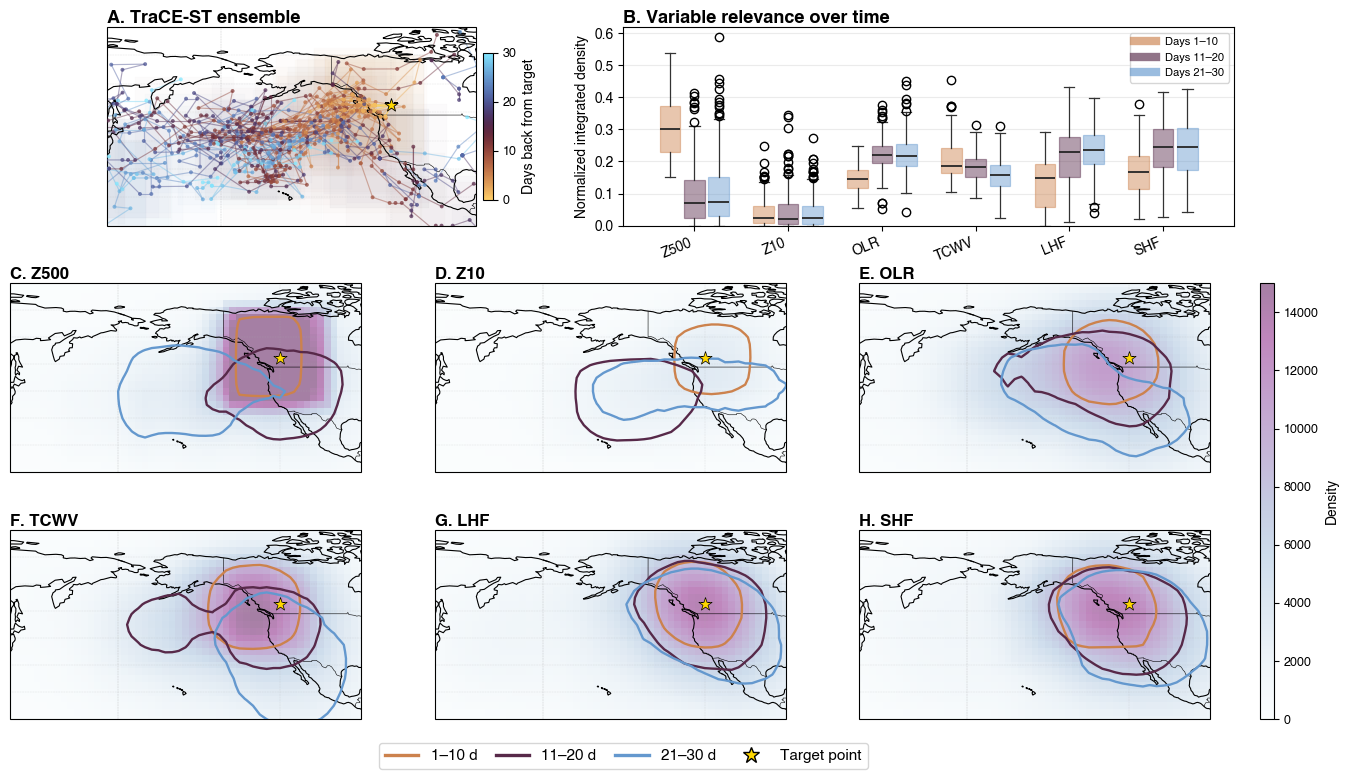

In [37]:
# =========================================================
# Make new Figure 4
# =========================================================

run_id = 205

params_sel = load_run_params(run_id)
summary_sel = load_run_summary(run_id)
results_sel = load_run_results(run_id)

print("Loaded run:", run_id)
print("n_requested:", summary_sel["n_requested"])
print("n_success:", summary_sel["n_success"])
print("n_failed:", summary_sel["n_failed"])

fig4_new = plot_trace_st_new_fig4_compact_right_cbar(
    results_sel=results_sel,
    params_sel=params_sel,
    pooled_members=pooled_members,
    full_data_run=full_data_run,
    run_id=run_id,
    windows=((0, 10), (10, 20), (20, 30)),
    window_labels=("1–10 d", "11–20 d", "21–30 d"),
    extent=(90, -40, 10, 80),
    central_longitude=180,
    event_lon=event_lon,
    event_lat=event_lat,
    cmap_name="managua",
    background_cmap="BuPu",
    background_vmax=15000,
    background_alpha=0.5,
    figsize=(14, 8),
)

plt.show()

# Optional save
fig4_new.savefig("fig_pnw21a.pdf", bbox_inches="tight")

In [45]:
# =========================================================
# Supplementary figure:
# 12 randomly selected TraCE-ST ensembles
# =========================================================

def plot_random_ensemble_gallery_supplement(
    *,
    df_keep,
    full_data_run,
    load_run_params,
    load_run_summary,
    load_run_results,
    n_runs=12,
    seed=42,
    extent=(90, -40, 10, 80),
    central_longitude=180,
    event_lon=None,
    event_lat=None,
    cmap_name="managua",
    figsize=(15, 9),
    timeres_hours=24.0,
):
    """
    Plot a 3 x 4 gallery of randomly selected TraCE-ST ensembles,
    using the same style as panel A in the main Fig. 4.
    """

    rng = np.random.default_rng(seed)

    available_runs = np.asarray(df_keep["run_id"].values, dtype=int)
    n_runs = min(int(n_runs), len(available_runs))

    selected_runs = rng.choice(available_runs, size=n_runs, replace=False)

    ncols = 4
    nrows = int(np.ceil(n_runs / ncols))

    proj = ccrs.PlateCarree(central_longitude=central_longitude)
    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=figsize,
        subplot_kw=dict(projection=proj),
        squeeze=False,
    )

    lag_norm = None
    lag_cmap = None

    for i, run_id in enumerate(selected_runs):
        row = i // ncols
        col = i % ncols
        ax = axes[row, col]

        params_sel = load_run_params(int(run_id))
        summary_sel = load_run_summary(int(run_id))
        results_sel = load_run_results(int(run_id))

        lag_norm, lag_cmap = _draw_selected_ensemble_panel_v3(
            ax,
            results_sel,
            full_data_run,
            box_size=params_sel["box_size"],
            timeres_hours=timeres_hours,
            extent=extent,
            central_longitude=central_longitude,
            title=(
                f"{chr(65+i)}. Run {int(run_id):3d} "
            ),
            cmap_name=cmap_name,
            lag_vmin=0,
            lag_vmax=30,
            line_alpha=0.45,
            line_width=0.85,
            point_alpha=0.75,
            point_size=8,
            show_boxes=True,
            box_alpha=0.02,
            box_edge_alpha=0.02,
            box_linewidth=0.3,
            box_every=2,
            n_members_boxes=4,
            seed_boxes=4,
            box_fill=True,
            event_lon=event_lon,
            event_lat=event_lat,
        )

    # Hide unused axes if n_runs < nrows*ncols
    for j in range(n_runs, nrows * ncols):
        row = j // ncols
        col = j % ncols
        axes[row, col].axis("off")

    # Shared colorbar
    if lag_norm is not None and lag_cmap is not None:
        cax = fig.add_axes([0.92, 0.18, 0.012, 0.64])
        sm = mpl.cm.ScalarMappable(norm=lag_norm, cmap=lag_cmap)
        sm.set_array([])
        cb = fig.colorbar(sm, cax=cax, orientation="vertical")
        cb.set_label("Days back from target", fontsize=11)
        cb.ax.tick_params(labelsize=9)

    fig.subplots_adjust(
        left=0.035,
        right=0.90,
        top=0.94,
        bottom=0.05,
        wspace=0.08,
        hspace=0.20,
    )

    print("Selected runs:", selected_runs.tolist())

    return fig, axes, selected_runs

Selected runs: [121, 292, 223, 150, 185, 248, 23, 119, 25, 204, 299, 55]


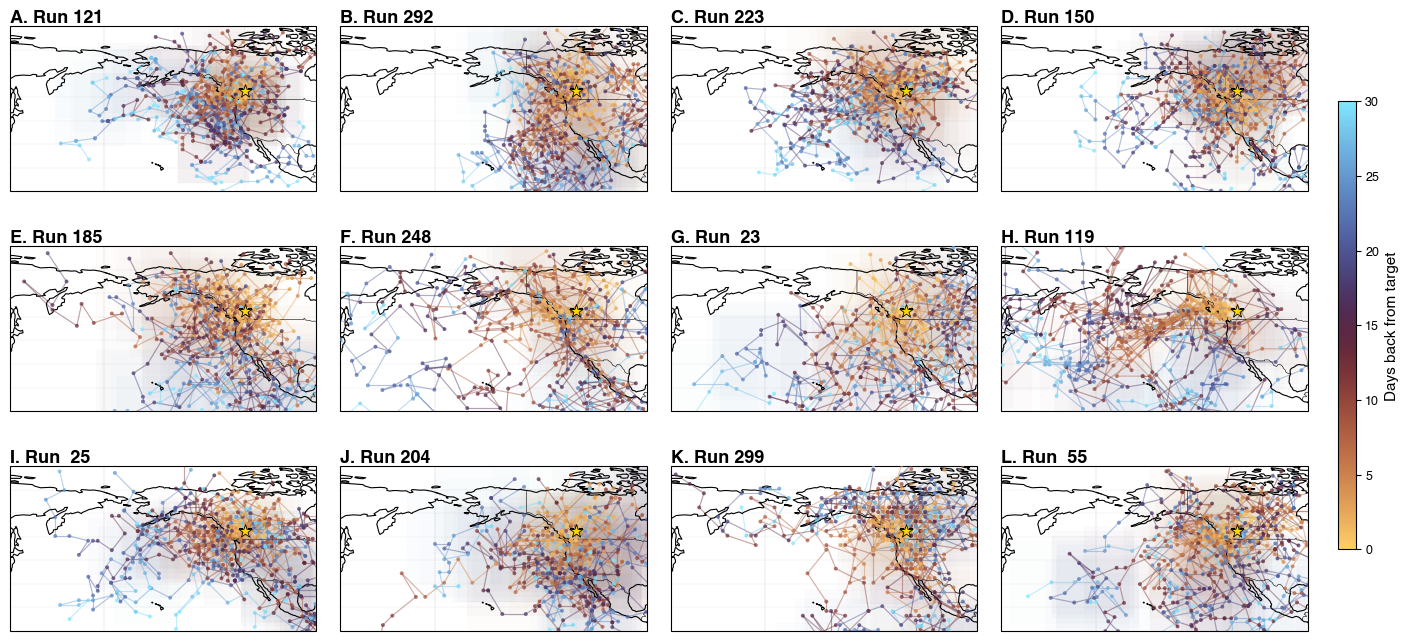

In [50]:
fig_supp_ensembles, axes_supp_ensembles, selected_runs = plot_random_ensemble_gallery_supplement(
    df_keep=df_keep,
    full_data_run=full_data_run,
    load_run_params=load_run_params,
    load_run_summary=load_run_summary,
    load_run_results=load_run_results,
    n_runs=12,
    seed=42,
    extent=(90, -40, 10, 80),
    central_longitude=180,
    event_lon=event_lon,
    event_lat=event_lat,
    cmap_name="managua",
    figsize=(15, 7),
    timeres_hours=24.0,
)

plt.show()

# Optional save
fig_supp_ensembles.savefig("sup_pnw21_random_ensembles.pdf", bbox_inches="tight")